# 02 - Build treatment timing from protected areas and land-titling boundaries

This notebook turns the cleaned grid-year panel from Notebook 01 into a treatment-ready panel with explicit timing for protected areas and land titling.

It does six things:

1. loads the panel saved by Notebook 01 and matches it to the correct grid geometry,
2. retrieves Colombian protected-area boundaries from the WDPA catalog in Google Earth Engine and caches the latest filtered snapshot locally,
3. reads the local `afro`, `indigenas`, and `campesinos` titling layers from `data/raw/boundaries/`,
4. constructs cell-level first-treatment years for `protected_area`, `afro`, `indigena`, `campesino`, and `land_title_any`,
5. expands a selected primary treatment into the generic columns used downstream: `first_treat_year`, `treated_it`, `not_yet_treated`, `event_time`, and cohort variables,
6. saves summary outputs and maps, including a 2024 deforestation overlay with departments and all treatment boundaries.

By default, the generic treatment columns use `protected_area` as the primary treatment. If you want later notebooks to treat land titling as the main treatment instead, change `PRIMARY_TREATMENT_KEY` in the user-configuration cell.

Units treated before the panel starts are retained and flagged. That keeps the coding transparent, but those units may need to be excluded or handled separately in later staggered-adoption estimators.

In [ ]:
from pathlib import Path
import importlib.metadata as ilm
import json
import platform
import re
import sys
import unicodedata
import warnings
from datetime import datetime

def detect_project_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for p in candidates:
        if (p / "notebooks").exists():
            return p
    return cwd

PROJECT_ROOT = detect_project_root()
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

import ee
import geemap
import geopandas as gpd
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from utils.treatment_lookup_utils import build_lookup_from_timed_polygons_fast, prepare_lookup_grid

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERMEDIATE_DIR = DATA_DIR / "intermediate"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
MAP_DIR = OUTPUT_DIR / "maps"
TABLE_DIR = OUTPUT_DIR / "tables"
CONFIG_DIR = PROJECT_ROOT / "configs"

for p in [DATA_DIR, RAW_DIR, INTERMEDIATE_DIR, PROCESSED_DIR, OUTPUT_DIR, FIG_DIR, MAP_DIR, TABLE_DIR, CONFIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

## Environment snapshot

This cell records the main package versions used by the notebook and tries to write a small manifest to `configs/environment_manifest_02.json`.

In this workspace the `configs/` directory may be read-only. If so, the cell prints a warning and continues.

In [ ]:
def get_version(pkg_name):
    try:
        return ilm.version(pkg_name)
    except Exception:
        return None

env_manifest = {
    "created_at_local": datetime.now().astimezone().isoformat(timespec="seconds"),
    "python": sys.version,
    "platform": platform.platform(),
    "packages": {
        "earthengine-api": get_version("earthengine-api"),
        "geemap": get_version("geemap"),
        "geopandas": get_version("geopandas"),
        "matplotlib": get_version("matplotlib"),
        "numpy": get_version("numpy"),
        "pandas": get_version("pandas"),
        "pyarrow": get_version("pyarrow"),
        "pyogrio": get_version("pyogrio"),
        "shapely": get_version("shapely"),
    },
}

manifest_path = CONFIG_DIR / "environment_manifest_02.json"
try:
    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(env_manifest, f, indent=2)
    print("Saved:", manifest_path)
except PermissionError as exc:
    print(f"Warning: could not write {manifest_path}: {exc}")

print(json.dumps(env_manifest, indent=2)[:1800])

## Optional project config from Notebook 00

If `configs/project_config.json` exists, this notebook loads it. Otherwise, it continues with the defaults set below.

In [ ]:
PROJECT_CONFIG = {}
project_config_path = CONFIG_DIR / "project_config.json"

if project_config_path.exists():
    with open(project_config_path, "r", encoding="utf-8") as f:
        PROJECT_CONFIG = json.load(f)
    print("Loaded project config:", project_config_path)
else:
    print("Project config not found. Continuing with notebook defaults.")

## User configuration

Edit this section before running the notebook.

The notebook now has two treatment families:

- `protected_area`: built from the WDPA dataset in Google Earth Engine,
- land titling: built from the local `afro`, `indigenas`, and `campesinos` boundary files in `data/raw/boundaries/`.

The notebook keeps treatment timing for all layers, and then exposes one selected treatment through the generic columns that later notebooks expect.

In [45]:
PANEL_INPUT_PATH = None
GRID_INPUT_PATH = None

PANEL_CELL_ID_COL = "cell_id"
PANEL_YEAR_COL = "year"
GRID_CELL_ID_COL = "cell_id"

PRIMARY_TREATMENT_KEY = "protected_area"

GEE_PROJECT = PROJECT_CONFIG.get("gee_project")
WDPA_ENABLED = True
WDPA_PREFERRED_MONTH = 12
WDPA_MIN_SNAPSHOT_YEAR = 2017
WDPA_ALLOWED_STATUS = ["Designated", "Inscribed"]
WDPA_STATUS_YEAR_CANDIDATES = ["STATUS_YR", "STATUS_YEAR"]
WDPA_YEARLY_CACHE_PATH = INTERMEDIATE_DIR / "wdpa_colombia_yearly_snapshots.geojson"
WDPA_YEARLY_PARQUET_PATH = INTERMEDIATE_DIR / "wdpa_colombia_yearly_snapshots.parquet"
WDPA_YEARLY_METADATA_PATH = INTERMEDIATE_DIR / "wdpa_colombia_yearly_snapshots_metadata.json"
REFRESH_WDPA_CACHE = False
WDPA_INCLUDE_MARINE = False

BOUNDARIES_DIR = RAW_DIR / "boundaries"
AFRO_DIR = BOUNDARIES_DIR / "afro"
INDIGENA_DIR = BOUNDARIES_DIR / "indigenas"
CAMPESINO_DIR = BOUNDARIES_DIR / "campesinos"
DEPARTAMENTO_DIR = BOUNDARIES_DIR / "departamentos"
LAND_TITLE_LAYER_KEYS = ["afro", "indigena", "campesino"]

POLYGON_OVERLAY_RULE = "any"
MIN_CELL_OVERLAP_SHARE = 0.01
AREA_CRS = "EPSG:6933"
TREATMENT_YEAR_FLOOR = 1900
MIN_TREATMENT_YEAR = None
MAX_TREATMENT_YEAR = None

LOSS_YEAR_FOR_MAP = 2024

PANEL_TREATMENT_NAME = "panel_treatment.parquet"
CELL_TREATMENT_NAME = "cell_treatment_lookup.parquet"
LAYER_SUMMARY_TABLE_NAME = "02_treatment_layer_summary.csv"
COHORT_TABLE_NAME = "02_primary_cohort_summary.csv"
SUMMARY_JSON_NAME = "02_treatment_timing_summary.json"
WDPA_YEARLY_SUMMARY_TABLE_NAME = "02_wdpa_area_by_year.csv"
COHORT_FIG_NAME = "02_primary_cohort_sizes.png"
WDPA_YEARLY_FIG_NAME = "02_wdpa_area_by_year.png"
LAND_TITLE_AREA_FIG_NAME = "02_land_title_area_by_year.png"
TITLING_GRID_EVOLUTION_FIG_NAME = "02_titling_grid_cells_over_time.png"
TREATMENT_TYPE_FIG_NAME = "02_treatment_type_grid_cells.png"
LOSS_SUMMARY_MAP_NAME = "02_map_avg_annual_loss_with_boundaries_hist.png"
INTERACTIVE_LOSS_SUMMARY_MAP_NAME = "02_interactive_avg_annual_loss_boundaries.html"
WRITE_CANONICAL_ALIASES = True


## Helper functions

These helpers keep the notebook self-contained while still handling the specific treatment sources used in this project.

In [50]:
def ensure_exists(path_like, label):
    path = Path(path_like)
    if not path.exists():
        raise FileNotFoundError(f"{label} not found: {path}")
    return path

def resolve_latest_input(explicit_path, glob_pattern):
    if explicit_path is not None:
        return ensure_exists(explicit_path, "Input file")
    candidates = sorted(INTERMEDIATE_DIR.glob(glob_pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f"No files matched {glob_pattern!r} in {INTERMEDIATE_DIR}")
    return candidates[0]

def infer_run_tag_from_panel(panel_path):
    stem = Path(panel_path).stem
    prefix = "panel_raw_long"
    if not stem.startswith(prefix):
        return ""
    return stem[len(prefix):].lstrip("_")

def append_tag_to_filename(filename, tag):
    path = Path(filename)
    suffix = "".join(path.suffixes)
    stem = path.name[:-len(suffix)] if suffix else path.name
    return f"{stem}_{tag}{suffix}" if tag else path.name

def choose_best_grid_path(panel_df, explicit_grid_path=None, grid_pattern="grid_geometry*.geojson"):
    panel_ids = set(panel_df[PANEL_CELL_ID_COL].astype("string").unique())
    if explicit_grid_path is not None:
        candidates = [ensure_exists(explicit_grid_path, "Grid geometry file")]
    else:
        candidates = sorted(INTERMEDIATE_DIR.glob(grid_pattern))
    if not candidates:
        raise FileNotFoundError(f"No grid geometry files matched {grid_pattern!r} in {INTERMEDIATE_DIR}")

    scored = []
    for candidate in candidates:
        gdf = gpd.read_file(candidate)
        if GRID_CELL_ID_COL not in gdf.columns:
            continue
        grid_ids = set(gdf[GRID_CELL_ID_COL].astype("string").unique())
        shared = len(panel_ids & grid_ids)
        scored.append((shared, -abs(len(grid_ids) - len(panel_ids)), candidate, gdf))
    if not scored:
        raise ValueError("No candidate grid file contained the expected grid cell id column.")
    scored.sort(reverse=True, key=lambda item: (item[0], item[1]))
    best_shared, _, best_path, best_gdf = scored[0]
    if best_shared == 0:
        raise ValueError("No overlap was found between the panel cell ids and the candidate grid files.")
    return best_path, best_gdf

def resolve_single_vector_file(folder_path):
    folder = ensure_exists(folder_path, "Boundary folder")
    candidates = sorted(Path(folder).rglob("*.shp"))
    if not candidates:
        candidates = sorted(Path(folder).rglob("*.gpkg"))
    if not candidates:
        candidates = sorted(Path(folder).rglob("*.geojson"))
    if not candidates:
        raise FileNotFoundError(f"No vector file found inside {folder}")
    return candidates[0]

def read_geospatial_source(path_like):
    path = ensure_exists(path_like, "Geospatial source")
    if path.suffix.lower() == ".parquet":
        gdf = gpd.read_parquet(path)
    else:
        gdf = gpd.read_file(path)
    if "geometry" not in gdf.columns:
        raise ValueError(f"The source does not contain a geometry column: {path}")
    return gdf

def try_write_json(payload, path_like):
    path = Path(path_like)
    try:
        with open(path, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)
        print("Saved:", path)
    except PermissionError as exc:
        print(f"Warning: could not write {path}: {exc}")

def normalize_token(value):
    text = unicodedata.normalize("NFKD", str(value))
    text = text.encode("ascii", "ignore").decode("ascii")
    return re.sub(r"[^a-z0-9]+", "", text.lower())

def find_matching_column(df, candidates):
    normalized = {normalize_token(col): col for col in df.columns}
    for candidate in candidates:
        key = normalize_token(candidate)
        if key in normalized:
            return normalized[key]
    return None

def coerce_year_series(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        years = series.dt.year
    else:
        numeric = pd.to_numeric(series, errors="coerce")
        if numeric.notna().any():
            years = numeric
        else:
            parsed = pd.to_datetime(series, errors="coerce")
            years = parsed.dt.year
    return pd.Series(years, index=series.index).round().astype("Int64")

def extract_year_from_text(series):
    extracted = series.astype("string").str.extract(r"((?:19|20)\d{2})")[0]
    return pd.to_numeric(extracted, errors="coerce").round().astype("Int64")

def enforce_year_bounds(series, min_year=None, max_year=None):
    out = pd.Series(series, copy=True)
    if min_year is not None:
        out = out.where(out >= min_year)
    if max_year is not None:
        out = out.where(out <= max_year)
    return out.astype("Int64")

def rowwise_int_min(df, columns):
    if not columns:
        return pd.Series(pd.array([pd.NA] * len(df), dtype="Int64"), index=df.index)
    numeric = df[columns].apply(pd.to_numeric, errors="coerce")
    values = numeric.min(axis=1, skipna=True)
    values = values.where(values.notna(), pd.NA)
    return values.round().astype("Int64")

def save_fig(path_like):
    path = Path(path_like)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure:", path)

In [51]:
def initialize_earth_engine(project=None):
    try:
        if project:
            ee.Initialize(project=project)
        else:
            ee.Initialize()
    except Exception:
        ee.Authenticate()
        if project:
            ee.Initialize(project=project)
        else:
            ee.Initialize()

def asset_exists(asset_id):
    try:
        ee.FeatureCollection(asset_id).limit(1).size().getInfo()
        return True
    except Exception:
        return False

def find_wdpa_snapshot_for_year(year, preferred_month=12):
    min_month = 7 if int(year) == 2017 else 1
    for month in range(int(preferred_month), min_month - 1, -1):
        asset_id = f"WCMC/WDPA/{int(year)}{month:02d}/polygons"
        if asset_exists(asset_id):
            return asset_id
    raise ValueError(f"No WDPA snapshot asset found for year={year}.")

def get_colombia_boundary_ee():
    try:
        fc = ee.FeatureCollection("FAO/GAUL/2015/level0")
        return fc.filter(ee.Filter.eq("ADM0_NAME", "Colombia")).geometry()
    except Exception:
        fc = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017")
        return fc.filter(ee.Filter.eq("country_na", "Colombia")).geometry()

def ee_featurecollection_to_gdf(fc, default_crs="EPSG:4326"):
    gdf = ee.data.computeFeatures(
        {
            "expression": fc,
            "fileFormat": "GEOPANDAS_GEODATAFRAME",
        }
    )
    if gdf is None:
        return gpd.GeoDataFrame({"geometry": []}, geometry="geometry", crs=default_crs)
    if not isinstance(gdf, gpd.GeoDataFrame):
        gdf = gpd.GeoDataFrame(gdf)
    if "geometry" not in gdf.columns:
        raise ValueError("Earth Engine returned a table without a geometry column.")
    if gdf.crs is None:
        gdf = gdf.set_crs(default_crs, allow_override=True)
    return gdf

def count_features(fc):
    try:
        return int(fc.size().getInfo())
    except Exception:
        return 0

def build_filtered_wdpa_fc(asset_id, colombia):
    base = ee.FeatureCollection(asset_id).filterBounds(colombia)
    diagnostics = {
        "asset_id": asset_id,
        "after_filterBounds": count_features(base),
    }
    if diagnostics["after_filterBounds"] == 0:
        diagnostics["final_count"] = 0
        return base, diagnostics

    fc = base

    iso_filters = [
        ("ISO3", ee.Filter.eq("ISO3", "COL")),
        ("PARENT_ISO3", ee.Filter.stringContains("PARENT_ISO3", "COL")),
    ]
    for field_name, ee_filter in iso_filters:
        try:
            candidate = base.filter(ee_filter)
            n = count_features(candidate)
            diagnostics[f"after_{field_name}"] = n
            if n > 0:
                fc = candidate
                diagnostics["iso_field_used"] = field_name
                break
        except Exception:
            continue

    if WDPA_ALLOWED_STATUS:
        status_values = sorted(
            set(
                list(WDPA_ALLOWED_STATUS)
                + [str(s).upper() for s in WDPA_ALLOWED_STATUS]
                + [str(s).title() for s in WDPA_ALLOWED_STATUS]
            )
        )
        try:
            candidate = fc.filter(ee.Filter.inList("STATUS", status_values))
            n = count_features(candidate)
            diagnostics["after_STATUS"] = n
            if n > 0:
                fc = candidate
                diagnostics["status_filter_applied"] = True
            else:
                diagnostics["status_filter_applied"] = False
        except Exception:
            diagnostics["status_filter_applied"] = False

    if not WDPA_INCLUDE_MARINE:
        try:
            candidate = fc.filter(ee.Filter.eq("MARINE", 0))
            n = count_features(candidate)
            diagnostics["after_MARINE_0"] = n
            if n > 0:
                fc = candidate
                diagnostics["marine_filter_applied"] = True
            else:
                diagnostics["marine_filter_applied"] = False
        except Exception:
            diagnostics["marine_filter_applied"] = False

    diagnostics["final_count"] = count_features(fc)
    return fc, diagnostics

def parse_snapshot_label(asset_id):
    token = asset_id.split("/")[2]
    if token == "current":
        return token, datetime.now().year
    match = re.search(r"(20\d{2})", token)
    year = int(match.group(1)) if match else datetime.now().year
    return token, year

def fetch_wdpa_yearly_gdf(refresh_cache=False, start_year=None, end_year=None):
    cache_path = Path(WDPA_YEARLY_CACHE_PATH)
    parquet_path = Path(WDPA_YEARLY_PARQUET_PATH)
    meta_path = Path(WDPA_YEARLY_METADATA_PATH)

    requested_start_year = max(int(start_year or WDPA_MIN_SNAPSHOT_YEAR), int(WDPA_MIN_SNAPSHOT_YEAR))
    requested_end_year = int(end_year or datetime.now().year)
    if requested_end_year < requested_start_year:
        raise ValueError(
            f"WDPA snapshot range is invalid: start_year={requested_start_year}, end_year={requested_end_year}."
        )

    if cache_path.exists() and not refresh_cache:
        if parquet_path.exists():
            gdf = gpd.read_parquet(parquet_path)
        else:
            gdf = gpd.read_file(cache_path)
            try:
                gdf.to_parquet(parquet_path)
            except Exception:
                pass
        metadata = {}
        if meta_path.exists():
            with open(meta_path, "r", encoding="utf-8") as f:
                metadata = json.load(f)
        if "wdpa_snapshot_year" in gdf.columns:
            cache_years = set(pd.Series(gdf["wdpa_snapshot_year"]).dropna().astype(int).unique().tolist())
            needed_years = set(range(requested_start_year, requested_end_year + 1))
            if needed_years.issubset(cache_years):
                gdf = gdf[pd.Series(gdf["wdpa_snapshot_year"]).astype("Int64").isin(sorted(needed_years))].copy()
                return gdf, metadata

    initialize_earth_engine(project=GEE_PROJECT)
    colombia = get_colombia_boundary_ee()

    yearly_frames = []
    year_records = []
    for year in range(requested_start_year, requested_end_year + 1):
        asset_id = find_wdpa_snapshot_for_year(year, preferred_month=WDPA_PREFERRED_MONTH)
        fc, diagnostics = build_filtered_wdpa_fc(asset_id, colombia)
        snapshot_label, _ = parse_snapshot_label(asset_id)
        year_record = {
            "year": int(year),
            "asset_id": asset_id,
            "snapshot": snapshot_label,
            **diagnostics,
        }
        if diagnostics.get("final_count", 0) <= 0:
            year_record["n_rows_with_valid_geometry"] = 0
            year_records.append(year_record)
            continue

        gdf_year = ee_featurecollection_to_gdf(fc)
        gdf_year = gdf_year[gdf_year.geometry.notna()].copy()
        gdf_year["wdpa_snapshot"] = snapshot_label
        gdf_year["wdpa_snapshot_year"] = int(year)
        gdf_year["wdpa_asset_id"] = asset_id
        year_record["n_rows_with_valid_geometry"] = int(gdf_year.shape[0])
        year_records.append(year_record)
        if not gdf_year.empty:
            yearly_frames.append(gdf_year)

    if not yearly_frames:
        raise ValueError(
            "WDPA yearly snapshot download returned no Colombian features. "
            f"Requested years: {requested_start_year}-{requested_end_year}."
        )

    combined = gpd.GeoDataFrame(
        pd.concat(yearly_frames, ignore_index=True),
        geometry="geometry",
        crs=yearly_frames[0].crs,
    )

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    combined.to_file(cache_path, driver="GeoJSON")
    try:
        combined.to_parquet(parquet_path)
    except Exception:
        pass

    metadata = {
        "gee_project": GEE_PROJECT,
        "requested_start_year": requested_start_year,
        "requested_end_year": requested_end_year,
        "n_rows_total": int(combined.shape[0]),
        "years_requested": list(range(requested_start_year, requested_end_year + 1)),
        "years_with_features": sorted(pd.Series(combined["wdpa_snapshot_year"]).dropna().astype(int).unique().tolist()),
        "year_assets": year_records,
        "cached_at_local": datetime.now().astimezone().isoformat(timespec="seconds"),
        "cache_path": str(cache_path),
        "parquet_cache_path": str(parquet_path),
    }
    try_write_json(metadata, meta_path)
    return combined, metadata


In [52]:
def first_nonmissing_value(values):
    series = pd.Series(values)
    for value in series:
        if pd.isna(value):
            continue
        if isinstance(value, str) and not value.strip():
            continue
        return value
    return pd.NA

def prepare_wdpa_treatment_data(wdpa_yearly_gdf, grid_gdf, panel_min_year, panel_max_year, grid_area_gdf=None):
    empty_lookup = pd.DataFrame(
        columns=[
            PANEL_CELL_ID_COL,
            "first_treat_year",
            "max_overlap_share",
            "total_overlap_area_m2",
            "source_rows",
            "treatment_key",
            "first_snapshot_year",
            "baseline_status_year",
        ]
    )
    empty_boundary = gpd.GeoDataFrame(
        {
            "wdpa_site_id": pd.Series(dtype="string"),
            "boundary_name": pd.Series(dtype="string"),
            "boundary_id": pd.Series(dtype="string"),
            "treat_year": pd.Series(dtype="Int64"),
            "first_snapshot_year": pd.Series(dtype="Int64"),
            "latest_snapshot_year": pd.Series(dtype="Int64"),
            "geometry": [],
        },
        geometry="geometry",
        crs=wdpa_yearly_gdf.crs if wdpa_yearly_gdf is not None and getattr(wdpa_yearly_gdf, "crs", None) is not None else "EPSG:4326",
    )
    empty_summary = pd.DataFrame(
        columns=["snapshot_year", "snapshot_label", "n_sites", "n_features", "union_area_km2"]
    )

    if wdpa_yearly_gdf is None or wdpa_yearly_gdf.empty:
        return {
            "timing_gdf": empty_boundary.copy(),
            "latest_site_gdf": empty_boundary,
            "lookup": empty_lookup,
            "yearly_summary": empty_summary,
            "status_year_column_used": None,
            "site_id_column_used": None,
            "earliest_snapshot_year": None,
            "latest_snapshot_year": None,
        }

    gdf = wdpa_yearly_gdf.copy()
    gdf = gdf[gdf.geometry.notna()].copy()
    try:
        gdf["geometry"] = gdf.geometry.make_valid()
    except Exception:
        pass
    gdf = gdf[gdf.geometry.notna()].copy()

    gdf["wdpa_snapshot_year"] = coerce_year_series(gdf["wdpa_snapshot_year"]).astype("Int64")
    gdf = gdf[gdf["wdpa_snapshot_year"].notna()].copy()
    gdf = gdf[gdf["wdpa_snapshot_year"] <= int(panel_max_year)].copy()
    if gdf.empty:
        return {
            "timing_gdf": empty_boundary.copy(),
            "latest_site_gdf": empty_boundary,
            "lookup": empty_lookup,
            "yearly_summary": empty_summary,
            "status_year_column_used": None,
            "site_id_column_used": None,
            "earliest_snapshot_year": None,
            "latest_snapshot_year": None,
        }

    grid_area = grid_area_gdf if grid_area_gdf is not None else prepare_lookup_grid(grid_gdf, grid_cell_id_col=GRID_CELL_ID_COL, area_crs=AREA_CRS)

    site_id_col = find_matching_column(gdf, ["SITE_ID", "WDPAID", "SITE_PID", "METADATAID"])
    if site_id_col is not None:
        gdf["wdpa_site_id"] = gdf[site_id_col].astype("string")
    else:
        gdf["wdpa_site_id"] = pd.Series([f"wdpa_site_{i}" for i in range(len(gdf))], index=gdf.index, dtype="string")
    fallback_site_ids = pd.Series([f"wdpa_site_{i}" for i in range(len(gdf))], index=gdf.index, dtype="string")
    gdf["wdpa_site_id"] = gdf["wdpa_site_id"].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA}).fillna(fallback_site_ids)

    name_col = find_matching_column(gdf, ["NAME", "NAME_ENG", "DESIG_ENG", "DESIG"])
    if name_col is not None:
        gdf["boundary_name"] = gdf[name_col].astype("string").str.strip()
    else:
        gdf["boundary_name"] = pd.Series([pd.NA] * len(gdf), index=gdf.index, dtype="string")
    fallback_names = pd.Series([f"Protected area {i + 1}" for i in range(len(gdf))], index=gdf.index, dtype="string")
    gdf["boundary_name"] = gdf["boundary_name"].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA}).fillna(gdf["wdpa_site_id"]).fillna(fallback_names)
    gdf["boundary_id"] = gdf["wdpa_site_id"].astype("string")

    status_year_col = find_matching_column(gdf, WDPA_STATUS_YEAR_CANDIDATES)
    if status_year_col is not None:
        status_year = coerce_year_series(gdf[status_year_col])
    else:
        status_year = pd.Series(pd.NA, index=gdf.index, dtype="Int64")
    status_year = enforce_year_bounds(
        status_year,
        min_year=max(TREATMENT_YEAR_FLOOR, MIN_TREATMENT_YEAR or TREATMENT_YEAR_FLOOR),
        max_year=MAX_TREATMENT_YEAR if MAX_TREATMENT_YEAR is not None else panel_max_year,
    )
    gdf["status_year"] = status_year.astype("Int64")

    snapshot_source = gdf[["wdpa_snapshot_year", "geometry"]].rename(columns={"wdpa_snapshot_year": "treat_year"})
    snapshot_lookup = build_lookup_from_timed_polygons_fast(
        snapshot_source,
        grid_area,
        "protected_area",
        panel_cell_id_col=PANEL_CELL_ID_COL,
        grid_cell_id_col=GRID_CELL_ID_COL,
        polygon_overlay_rule=POLYGON_OVERLAY_RULE,
        min_cell_overlap_share=MIN_CELL_OVERLAP_SHARE,
    )
    if snapshot_lookup.empty:
        snapshot_lookup["first_snapshot_year"] = pd.Series(dtype="Int64")
    else:
        snapshot_lookup = snapshot_lookup.rename(columns={"first_treat_year": "first_snapshot_year"})
        snapshot_lookup["first_snapshot_year"] = snapshot_lookup["first_snapshot_year"].astype("Int64")

    earliest_snapshot_year = int(gdf["wdpa_snapshot_year"].dropna().min())
    latest_snapshot_year = int(gdf["wdpa_snapshot_year"].dropna().max())

    baseline_source = gdf[
        (gdf["wdpa_snapshot_year"] == earliest_snapshot_year) & gdf["status_year"].notna()
    ][["status_year", "geometry"]].rename(columns={"status_year": "treat_year"})
    if baseline_source.empty:
        baseline_lookup = pd.DataFrame(columns=[PANEL_CELL_ID_COL, "baseline_status_year"])
    else:
        baseline_lookup = build_lookup_from_timed_polygons_fast(
            baseline_source,
            grid_area,
            "protected_area",
            panel_cell_id_col=PANEL_CELL_ID_COL,
            grid_cell_id_col=GRID_CELL_ID_COL,
            polygon_overlay_rule=POLYGON_OVERLAY_RULE,
            min_cell_overlap_share=MIN_CELL_OVERLAP_SHARE,
        )
        baseline_lookup = baseline_lookup[[PANEL_CELL_ID_COL, "first_treat_year"]].rename(
            columns={"first_treat_year": "baseline_status_year"}
        )
        baseline_lookup["baseline_status_year"] = baseline_lookup["baseline_status_year"].astype("Int64")

    if snapshot_lookup.empty:
        lookup = empty_lookup.copy()
    else:
        lookup = snapshot_lookup.merge(baseline_lookup, on=PANEL_CELL_ID_COL, how="left")
        lookup["first_treat_year"] = lookup["first_snapshot_year"].astype("Int64")
        mask = (
            lookup["first_snapshot_year"].notna()
            & (lookup["first_snapshot_year"] == earliest_snapshot_year)
            & lookup["baseline_status_year"].notna()
            & (lookup["baseline_status_year"] <= lookup["first_snapshot_year"])
        )
        lookup.loc[mask, "first_treat_year"] = lookup.loc[mask, "baseline_status_year"].astype("Int64")
        lookup["first_treat_year"] = lookup["first_treat_year"].astype("Int64")
        lookup["treatment_key"] = "protected_area"

    site_history = (
        gdf.sort_values(["wdpa_snapshot_year", "wdpa_site_id"])
        .groupby("wdpa_site_id", as_index=False)
        .agg(
            boundary_name=("boundary_name", first_nonmissing_value),
            boundary_id=("boundary_id", first_nonmissing_value),
            first_snapshot_year=("wdpa_snapshot_year", "min"),
            first_status_year=("status_year", "min"),
            latest_snapshot_year=("wdpa_snapshot_year", "max"),
        )
    )
    site_history["first_snapshot_year"] = site_history["first_snapshot_year"].astype("Int64")
    site_history["first_status_year"] = site_history["first_status_year"].astype("Int64")
    site_history["latest_snapshot_year"] = site_history["latest_snapshot_year"].astype("Int64")
    site_history["treat_year"] = rowwise_int_min(site_history, ["first_status_year", "first_snapshot_year"])

    latest_snapshot = gdf[gdf["wdpa_snapshot_year"] == latest_snapshot_year][["wdpa_site_id", "geometry"]].copy()
    latest_snapshot = latest_snapshot.merge(
        site_history[["wdpa_site_id", "boundary_name", "boundary_id", "treat_year", "first_snapshot_year", "latest_snapshot_year"]],
        on="wdpa_site_id",
        how="left",
    )
    try:
        latest_snapshot["geometry"] = latest_snapshot.geometry.make_valid()
    except Exception:
        pass

    latest_geometry = latest_snapshot[["wdpa_site_id", "geometry"]].copy().dissolve(by="wdpa_site_id").reset_index()
    latest_attributes = (
        latest_snapshot[["wdpa_site_id", "boundary_name", "boundary_id", "treat_year", "first_snapshot_year", "latest_snapshot_year"]]
        .drop_duplicates(subset=["wdpa_site_id"])
        .copy()
    )
    latest_site_gdf = latest_attributes.merge(latest_geometry, on="wdpa_site_id", how="inner")
    latest_site_gdf = gpd.GeoDataFrame(latest_site_gdf, geometry="geometry", crs=latest_snapshot.crs)
    latest_site_gdf["treatment_key"] = "protected_area"

    yearly_rows = []
    for year in sorted(gdf["wdpa_snapshot_year"].dropna().astype(int).unique().tolist()):
        year_df = gdf[gdf["wdpa_snapshot_year"] == int(year)].copy()
        year_area_df = year_df[["wdpa_site_id", "geometry"]].copy().to_crs(AREA_CRS)
        union_area_km2 = float(year_area_df.geometry.unary_union.area / 1_000_000.0) if not year_area_df.empty else 0.0
        yearly_rows.append(
            {
                "snapshot_year": int(year),
                "snapshot_label": first_nonmissing_value(year_df["wdpa_snapshot"]) if "wdpa_snapshot" in year_df.columns else str(year),
                "n_sites": int(year_df["wdpa_site_id"].nunique()),
                "n_features": int(year_df.shape[0]),
                "union_area_km2": union_area_km2,
            }
        )
    yearly_summary = pd.DataFrame(yearly_rows).sort_values("snapshot_year").reset_index(drop=True)

    return {
        "timing_gdf": gdf,
        "latest_site_gdf": latest_site_gdf,
        "lookup": lookup,
        "yearly_summary": yearly_summary,
        "status_year_column_used": status_year_col,
        "site_id_column_used": site_id_col,
        "earliest_snapshot_year": earliest_snapshot_year,
        "latest_snapshot_year": latest_snapshot_year,
    }

def prepare_land_title_layer(layer_key, folder_path, year_candidates, panel_max_year, backup_text_candidates=None):
    source_path = resolve_single_vector_file(folder_path)
    gdf = read_geospatial_source(source_path)
    gdf = gdf[gdf.geometry.notna()].copy()
    year_col = find_matching_column(gdf, year_candidates)
    backup_col = find_matching_column(gdf, backup_text_candidates or [])
    if year_col is not None:
        treat_year = coerce_year_series(gdf[year_col])
    else:
        treat_year = pd.Series(pd.NA, index=gdf.index, dtype="Int64")
    if backup_col is not None:
        extracted = extract_year_from_text(gdf[backup_col])
        treat_year = treat_year.where(treat_year.notna(), extracted)
    treat_year = enforce_year_bounds(
        treat_year,
        min_year=max(TREATMENT_YEAR_FLOOR, MIN_TREATMENT_YEAR or TREATMENT_YEAR_FLOOR),
        max_year=MAX_TREATMENT_YEAR if MAX_TREATMENT_YEAR is not None else panel_max_year,
    )
    gdf["treat_year"] = treat_year
    gdf = gdf[gdf["treat_year"].notna()].copy()
    gdf["treatment_key"] = layer_key
    metadata = {
        "layer_key": layer_key,
        "source_path": str(source_path),
        "year_column_used": year_col,
        "backup_text_column_used": backup_col,
        "n_rows_with_valid_year": int(gdf.shape[0]),
    }
    return gdf, metadata

def build_lookup_from_timed_polygons(source_gdf, grid_gdf, treatment_key):
    if source_gdf.empty:
        return pd.DataFrame(columns=[PANEL_CELL_ID_COL, "first_treat_year", "max_overlap_share", "total_overlap_area_m2", "source_rows", "treatment_key"])
    source = source_gdf[["treat_year", "geometry"]].copy()
    try:
        source["geometry"] = source.geometry.make_valid()
    except Exception:
        pass
    source = source[source.geometry.notna()].copy()
    source = source.dropna(subset=["treat_year"]).copy()
    if source.empty:
        return pd.DataFrame(columns=[PANEL_CELL_ID_COL, "first_treat_year", "max_overlap_share", "total_overlap_area_m2", "source_rows", "treatment_key"])
    source["treat_year"] = source["treat_year"].astype("Int64")
    source = source.dissolve(by="treat_year").reset_index()

    grid = grid_gdf[[GRID_CELL_ID_COL, "geometry"]].copy()
    grid = grid[grid.geometry.notna()].drop_duplicates(subset=[GRID_CELL_ID_COL]).copy()
    grid = grid.to_crs(AREA_CRS)
    source = source.to_crs(AREA_CRS)
    grid["cell_area_m2"] = grid.geometry.area

    overlay = gpd.overlay(
        grid[[GRID_CELL_ID_COL, "cell_area_m2", "geometry"]],
        source[["treat_year", "geometry"]],
        how="intersection",
        keep_geom_type=False,
    )
    if overlay.empty:
        return pd.DataFrame(columns=[PANEL_CELL_ID_COL, "first_treat_year", "max_overlap_share", "total_overlap_area_m2", "source_rows", "treatment_key"])
    overlay["overlap_area_m2"] = overlay.geometry.area
    overlay["overlap_share"] = overlay["overlap_area_m2"] / overlay["cell_area_m2"]
    if POLYGON_OVERLAY_RULE == "share":
        overlay = overlay[overlay["overlap_share"] >= float(MIN_CELL_OVERLAP_SHARE)].copy()
    elif POLYGON_OVERLAY_RULE == "any":
        overlay = overlay[overlay["overlap_area_m2"] > 0].copy()
    else:
        raise ValueError("POLYGON_OVERLAY_RULE must be either 'any' or 'share'.")

    lookup = (
        overlay.groupby(GRID_CELL_ID_COL, as_index=False)
        .agg(
            first_treat_year=("treat_year", "min"),
            max_overlap_share=("overlap_share", "max"),
            total_overlap_area_m2=("overlap_area_m2", "sum"),
            source_rows=("treat_year", "size"),
        )
        .rename(columns={GRID_CELL_ID_COL: PANEL_CELL_ID_COL})
    )
    lookup["first_treat_year"] = lookup["first_treat_year"].astype("Int64")
    lookup["treatment_key"] = treatment_key
    return lookup

def combine_treatment_lookups(panel_cell_ids, layer_lookups):
    base = pd.DataFrame({PANEL_CELL_ID_COL: pd.Series(sorted(set(panel_cell_ids)), dtype="string")})
    for key, lookup in layer_lookups.items():
        suffix = f"_{key}"
        rename_map = {
            "first_treat_year": f"first_treat_year{suffix}",
            "max_overlap_share": f"max_overlap_share{suffix}",
            "total_overlap_area_m2": f"total_overlap_area_m2{suffix}",
            "source_rows": f"source_rows{suffix}",
        }
        keep_cols = [c for c in [PANEL_CELL_ID_COL, "first_treat_year", "max_overlap_share", "total_overlap_area_m2", "source_rows"] if c in lookup.columns]
        base = base.merge(lookup[keep_cols].rename(columns=rename_map), on=PANEL_CELL_ID_COL, how="left")
        year_col = f"first_treat_year{suffix}"
        if year_col in base.columns:
            base[year_col] = base[year_col].astype("Int64")
            base[f"ever_{key}"] = base[year_col].notna().astype(int)

    land_year_cols = [f"first_treat_year_{key}" for key in LAND_TITLE_LAYER_KEYS if f"first_treat_year_{key}" in base.columns]
    land_ever_cols = [f"ever_{key}" for key in LAND_TITLE_LAYER_KEYS if f"ever_{key}" in base.columns]
    base["first_treat_year_land_title_any"] = rowwise_int_min(base, land_year_cols)
    base["ever_land_title_any"] = base[land_ever_cols].max(axis=1).fillna(0).astype(int) if land_ever_cols else 0
    base["n_land_title_types"] = base[land_ever_cols].sum(axis=1).fillna(0).astype(int) if land_ever_cols else 0

    def assign_land_title_factor(row):
        active = [key for key in LAND_TITLE_LAYER_KEYS if row.get(f"ever_{key}", 0) == 1]
        if len(active) == 0:
            return "none"
        if len(active) == 1:
            return active[0]
        return "multiple"

    base["land_title_factor"] = base.apply(assign_land_title_factor, axis=1)
    return base.sort_values(PANEL_CELL_ID_COL).reset_index(drop=True)

def attach_treatment_panel(panel_df, cell_treatment_lookup, primary_treatment_key):
    panel = panel_df.copy()
    panel[PANEL_CELL_ID_COL] = panel[PANEL_CELL_ID_COL].astype("string")
    panel = panel.merge(cell_treatment_lookup, on=PANEL_CELL_ID_COL, how="left", validate="many_to_one")
    layer_keys = ["protected_area"] + LAND_TITLE_LAYER_KEYS + ["land_title_any"]
    panel_start_year = int(panel[PANEL_YEAR_COL].min())
    for key in layer_keys:
        year_col = f"first_treat_year_{key}"
        if year_col not in panel.columns:
            continue
        panel[year_col] = panel[year_col].astype("Int64")
        panel[f"ever_{key}"] = panel[year_col].notna().astype(int)
        panel[f"treated_before_panel_start_{key}"] = (panel[year_col].notna() & (panel[year_col] < panel_start_year)).astype(int)
        panel[f"treated_it_{key}"] = (panel[year_col].notna() & (panel[PANEL_YEAR_COL].astype("Int64") >= panel[year_col])).astype(int)
        panel[f"not_yet_treated_{key}"] = (panel[year_col].notna() & (panel[PANEL_YEAR_COL].astype("Int64") < panel[year_col])).astype(int)
        panel[f"treatment_starts_this_year_{key}"] = (panel[year_col].notna() & (panel[PANEL_YEAR_COL].astype("Int64") == panel[year_col])).astype(int)
        panel[f"event_time_{key}"] = panel[PANEL_YEAR_COL].astype("Int64") - panel[year_col]

    primary_year_col = f"first_treat_year_{primary_treatment_key}"
    if primary_year_col not in panel.columns:
        raise ValueError(f"Primary treatment key {primary_treatment_key!r} is not available in the cell-level lookup.")
    panel["primary_treatment_key"] = primary_treatment_key
    panel["first_treat_year"] = panel[primary_year_col].astype("Int64")
    panel["cohort_year"] = panel["first_treat_year"].astype("Int64")
    panel["ever_treated"] = panel[f"ever_{primary_treatment_key}"].astype(int)
    panel["never_treated"] = panel["first_treat_year"].isna().astype(int)
    panel["treated_before_panel_start"] = panel[f"treated_before_panel_start_{primary_treatment_key}"].astype(int)
    panel["treated_it"] = panel[f"treated_it_{primary_treatment_key}"].astype(int)
    panel["not_yet_treated"] = panel[f"not_yet_treated_{primary_treatment_key}"].astype(int)
    panel["treatment_starts_this_year"] = panel[f"treatment_starts_this_year_{primary_treatment_key}"].astype(int)
    panel["event_time"] = panel[f"event_time_{primary_treatment_key}"].astype("Int64")
    return panel.sort_values([PANEL_CELL_ID_COL, PANEL_YEAR_COL]).reset_index(drop=True)

def validate_primary_treatment_panel(panel_df):
    duplicate_rows = int(panel_df.duplicated([PANEL_CELL_ID_COL, PANEL_YEAR_COL]).sum())
    if duplicate_rows:
        raise ValueError(f"Found {duplicate_rows} duplicate cell-year rows in the panel.")
    sorted_panel = panel_df.sort_values([PANEL_CELL_ID_COL, PANEL_YEAR_COL]).copy()
    down_switches = int(sorted_panel.groupby(PANEL_CELL_ID_COL)["treated_it"].diff().fillna(0).lt(0).sum())
    if down_switches:
        raise ValueError("The primary treatment indicator is not absorbing for some cells.")
    inconsistent_flags = int(((panel_df["ever_treated"] + panel_df["never_treated"]) != 1).sum())
    if inconsistent_flags:
        raise ValueError("ever_treated and never_treated are inconsistent for some rows.")
    overlap_flags = int(((panel_df["treated_it"] == 1) & (panel_df["not_yet_treated"] == 1)).sum())
    if overlap_flags:
        raise ValueError("treated_it and not_yet_treated overlap for some rows.")
    repeated_starts = panel_df.groupby(PANEL_CELL_ID_COL)["treatment_starts_this_year"].sum().gt(1).sum()
    if int(repeated_starts):
        raise ValueError("Some cells start treatment more than once.")
    cell_level = panel_df[[PANEL_CELL_ID_COL, "first_treat_year", "treated_before_panel_start"]].drop_duplicates()
    ever_treated_cells = int(cell_level["first_treat_year"].notna().sum())
    total_cells = int(cell_level.shape[0])
    never_treated_cells = total_cells - ever_treated_cells
    cohort_min = cell_level["first_treat_year"].dropna().min()
    cohort_max = cell_level["first_treat_year"].dropna().max()
    return {
        "n_panel_rows": int(panel_df.shape[0]),
        "n_cells": total_cells,
        "n_ever_treated_cells": ever_treated_cells,
        "n_never_treated_cells": never_treated_cells,
        "share_ever_treated_cells": float(ever_treated_cells / total_cells) if total_cells else 0.0,
        "n_treated_rows": int(panel_df["treated_it"].sum()),
        "first_cohort_year": int(cohort_min) if pd.notna(cohort_min) else None,
        "last_cohort_year": int(cohort_max) if pd.notna(cohort_max) else None,
        "n_cells_treated_before_panel_start": int(cell_level["treated_before_panel_start"].sum()),
    }


## Load the upstream panel and match the grid geometry

This block reads the cleaned panel from Notebook 01, auto-detects the latest panel file if needed, and chooses the grid geometry file with the best `cell_id` overlap.

In [53]:
panel_input_path = resolve_latest_input(PANEL_INPUT_PATH, "panel_raw_long*.parquet")
panel_df = pd.read_parquet(panel_input_path)
required_panel_cols = [PANEL_CELL_ID_COL, PANEL_YEAR_COL]
missing_panel_cols = [c for c in required_panel_cols if c not in panel_df.columns]
if missing_panel_cols:
    raise ValueError(f"Missing required columns in the panel file: {missing_panel_cols}")
panel_df[PANEL_CELL_ID_COL] = panel_df[PANEL_CELL_ID_COL].astype("string")
panel_df[PANEL_YEAR_COL] = coerce_year_series(panel_df[PANEL_YEAR_COL])
if panel_df[PANEL_YEAR_COL].isna().any():
    raise ValueError("The panel year column contains invalid or missing values.")
panel_df = panel_df.sort_values([PANEL_CELL_ID_COL, PANEL_YEAR_COL]).reset_index(drop=True)
run_tag = infer_run_tag_from_panel(panel_input_path)
panel_min_year = int(panel_df[PANEL_YEAR_COL].min())
panel_max_year = int(panel_df[PANEL_YEAR_COL].max())

valid_primary_keys = {"protected_area", "afro", "indigena", "campesino", "land_title_any"}
if PRIMARY_TREATMENT_KEY not in valid_primary_keys:
    raise ValueError(f"PRIMARY_TREATMENT_KEY must be one of {sorted(valid_primary_keys)}")
if LOSS_YEAR_FOR_MAP < panel_min_year or LOSS_YEAR_FOR_MAP > panel_max_year:
    raise ValueError(f"LOSS_YEAR_FOR_MAP={LOSS_YEAR_FOR_MAP} is outside the panel range [{panel_min_year}, {panel_max_year}].")

grid_path, grid_gdf = choose_best_grid_path(panel_df, GRID_INPUT_PATH)
grid_gdf[GRID_CELL_ID_COL] = grid_gdf[GRID_CELL_ID_COL].astype("string")
grid_gdf = grid_gdf.drop_duplicates(subset=[GRID_CELL_ID_COL]).copy()
panel_ids = set(panel_df[PANEL_CELL_ID_COL].unique())
grid_ids = set(grid_gdf[GRID_CELL_ID_COL].unique())
missing_grid_ids = sorted(panel_ids - grid_ids)
grid_gdf = grid_gdf[grid_gdf[GRID_CELL_ID_COL].isin(panel_ids)].copy()
grid_lookup_gdf = prepare_lookup_grid(grid_gdf, grid_cell_id_col=GRID_CELL_ID_COL, area_crs=AREA_CRS)
print("Panel input:", panel_input_path)
print("Grid geometry:", grid_path)
print("Panel rows:", panel_df.shape[0])
print("Panel cells:", panel_df[PANEL_CELL_ID_COL].nunique())
print("Year range:", panel_min_year, "-", panel_max_year)
print("Grid rows kept after filtering to panel ids:", grid_gdf.shape[0])
if missing_grid_ids:
    raise ValueError("The selected grid geometry does not cover every panel cell. Missing ids include: " + str(missing_grid_ids[:10]))

Panel input: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\intermediate\panel_raw_long_0p080.parquet
Grid geometry: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\intermediate\grid_geometry_0p080.geojson
Panel rows: 377100
Panel cells: 15084
Year range: 2001 - 2025
Grid rows kept after filtering to panel ids: 15084


## Load treatment sources and build the cell-level lookup

This block retrieves the WDPA protected-area layer from Google Earth Engine, reads the local land-titling layers, and overlays each boundary set onto the deforestation grid.

In [ ]:
layer_source_meta = {}
boundary_gdfs = {}
layer_lookups = {}

wdpa_yearly_summary_df = pd.DataFrame(
    columns=["snapshot_year", "snapshot_label", "n_sites", "n_features", "union_area_km2"]
)
protected_area_gdf = gpd.GeoDataFrame({"geometry": []}, geometry="geometry", crs="EPSG:4326")
protected_area_display_gdf = gpd.GeoDataFrame({"geometry": []}, geometry="geometry", crs="EPSG:4326")
wdpa_latest_gdf = protected_area_display_gdf.copy()

if WDPA_ENABLED:
    wdpa_start_year = max(int(WDPA_MIN_SNAPSHOT_YEAR), int(min(panel_min_year, panel_max_year)))
    wdpa_end_year = int(panel_max_year)
    wdpa_yearly_gdf, wdpa_meta = fetch_wdpa_yearly_gdf(
        refresh_cache=REFRESH_WDPA_CACHE,
        start_year=wdpa_start_year,
        end_year=wdpa_end_year,
    )
    wdpa_prepared = prepare_wdpa_treatment_data(
        wdpa_yearly_gdf,
        grid_gdf,
        panel_min_year=panel_min_year,
        panel_max_year=panel_max_year,
        grid_area_gdf=grid_lookup_gdf,
    )
    protected_area_gdf = wdpa_prepared["timing_gdf"]
    protected_area_display_gdf = wdpa_prepared["latest_site_gdf"]
    wdpa_latest_gdf = protected_area_display_gdf.copy()
    wdpa_yearly_summary_df = wdpa_prepared["yearly_summary"]
    layer_lookups["protected_area"] = wdpa_prepared["lookup"]
    layer_source_meta["protected_area"] = {
        **wdpa_meta,
        "status_year_column_used": wdpa_prepared["status_year_column_used"],
        "site_id_column_used": wdpa_prepared["site_id_column_used"],
        "timing_method": "yearly_snapshots_with_baseline_status_backfill",
        "n_rows_with_valid_year": int(protected_area_gdf.shape[0]),
        "first_snapshot_year": wdpa_prepared["earliest_snapshot_year"],
        "latest_snapshot_year": wdpa_prepared["latest_snapshot_year"],
    }
    boundary_gdfs["protected_area"] = protected_area_display_gdf
else:
    if PRIMARY_TREATMENT_KEY == "protected_area":
        raise ValueError("PRIMARY_TREATMENT_KEY cannot be 'protected_area' when WDPA_ENABLED is False.")
    layer_source_meta["protected_area"] = {"enabled": False}
    layer_lookups["protected_area"] = pd.DataFrame(
        columns=[PANEL_CELL_ID_COL, "first_treat_year", "max_overlap_share", "total_overlap_area_m2", "source_rows", "treatment_key"]
    )
    boundary_gdfs["protected_area"] = protected_area_display_gdf

afro_gdf, afro_meta = prepare_land_title_layer("afro", AFRO_DIR, ["ULTIMA_FEC"], panel_max_year=panel_max_year)
indigena_gdf, indigena_meta = prepare_land_title_layer("indigena", INDIGENA_DIR, ["ULTIMA_FEC"], panel_max_year=panel_max_year)
campesino_gdf, campesino_meta = prepare_land_title_layer(
    "campesino",
    CAMPESINO_DIR,
    ["Ano", "A?o"],
    panel_max_year=panel_max_year,
    backup_text_candidates=["ACTO_ADMIN"],
)
boundary_gdfs["afro"] = afro_gdf
boundary_gdfs["indigena"] = indigena_gdf
boundary_gdfs["campesino"] = campesino_gdf
layer_source_meta["afro"] = afro_meta
layer_source_meta["indigena"] = indigena_meta
layer_source_meta["campesino"] = campesino_meta

departamento_path = resolve_single_vector_file(DEPARTAMENTO_DIR)
departamentos_gdf = read_geospatial_source(departamento_path)

for key in ["afro", "indigena", "campesino"]:
    lookup = build_lookup_from_timed_polygons_fast(
        boundary_gdfs[key],
        grid_lookup_gdf,
        key,
        panel_cell_id_col=PANEL_CELL_ID_COL,
        grid_cell_id_col=GRID_CELL_ID_COL,
        polygon_overlay_rule=POLYGON_OVERLAY_RULE,
        min_cell_overlap_share=MIN_CELL_OVERLAP_SHARE,
    )
    layer_lookups[key] = lookup

for key in ["protected_area", "afro", "indigena", "campesino"]:
    lookup = layer_lookups[key]
    treated_cells = int(lookup["first_treat_year"].notna().sum()) if "first_treat_year" in lookup.columns else 0
    print(f"{key}: {treated_cells} treated cells")

if WDPA_ENABLED and not wdpa_yearly_summary_df.empty:
    print("WDPA yearly snapshots loaded:", wdpa_yearly_summary_df["snapshot_year"].min(), "to", wdpa_yearly_summary_df["snapshot_year"].max())
    print(wdpa_yearly_summary_df.to_string(index=False))

cell_treatment_lookup = combine_treatment_lookups(panel_df[PANEL_CELL_ID_COL].unique(), layer_lookups)
preview_cols = [
    PANEL_CELL_ID_COL,
    "first_treat_year_protected_area",
    "first_treat_year_afro",
    "first_treat_year_indigena",
    "first_treat_year_campesino",
    "first_treat_year_land_title_any",
    "land_title_factor",
]
print(cell_treatment_lookup[preview_cols].head(10).to_string(index=False))
print("Departamento boundaries:", departamento_path)


Saved: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\intermediate\wdpa_colombia_yearly_snapshots_metadata.json


## Expand the selected primary treatment to the full panel and validate it

The generic columns kept for later notebooks are built from `PRIMARY_TREATMENT_KEY`, but the panel also retains the per-layer timing columns for protected areas and each land-titling layer.

In [43]:
panel_treatment_df = attach_treatment_panel(panel_df, cell_treatment_lookup, primary_treatment_key=PRIMARY_TREATMENT_KEY)
validation_summary = validate_primary_treatment_panel(panel_treatment_df)
print("Primary treatment key:", PRIMARY_TREATMENT_KEY)
print(json.dumps(validation_summary, indent=2))
preview_cols = [
    PANEL_CELL_ID_COL,
    PANEL_YEAR_COL,
    "primary_treatment_key",
    "first_treat_year",
    "treated_it",
    "not_yet_treated",
    "event_time",
    "land_title_factor",
    "first_treat_year_protected_area",
    "first_treat_year_land_title_any",
]
print(panel_treatment_df[preview_cols].head(10).to_string(index=False))

Primary treatment key: protected_area
{
  "n_panel_rows": 377100,
  "n_cells": 15084,
  "n_ever_treated_cells": 4997,
  "n_never_treated_cells": 10087,
  "share_ever_treated_cells": 0.3312781755502519,
  "n_treated_rows": 87249,
  "first_cohort_year": 1938,
  "last_cohort_year": 2025,
  "n_cells_treated_before_panel_start": 2328
}
                cell_id  year primary_treatment_key  first_treat_year  treated_it  not_yet_treated  event_time land_title_factor  first_treat_year_protected_area  first_treat_year_land_title_any
lon_-66.9728_lat_1.1330  2001        protected_area              <NA>           0                0        <NA>          indigena                             <NA>                             1989
lon_-66.9728_lat_1.1330  2002        protected_area              <NA>           0                0        <NA>          indigena                             <NA>                             1989
lon_-66.9728_lat_1.1330  2003        protected_area              <NA>           0 

## Summary tables

This block creates a cohort summary for the selected primary treatment and a cross-layer summary that keeps the protected-area and land-titling overlays transparent.

In [42]:
primary_cell_timing = panel_treatment_df[[PANEL_CELL_ID_COL, "first_treat_year", "treated_before_panel_start"]].drop_duplicates()
cohort_summary = (
    primary_cell_timing.dropna(subset=["first_treat_year"])
    .groupby("first_treat_year", as_index=False)
    .agg(
        n_cells=(PANEL_CELL_ID_COL, "nunique"),
        n_cells_treated_before_panel_start=("treated_before_panel_start", "sum"),
    )
    .rename(columns={"first_treat_year": "cohort_year"})
    .sort_values("cohort_year")
    .reset_index(drop=True)
)
if cohort_summary.empty:
    cohort_summary = pd.DataFrame(columns=["cohort_year", "n_cells", "n_cells_treated_before_panel_start", "share_of_all_cells"])
else:
    cohort_summary["share_of_all_cells"] = cohort_summary["n_cells"] / primary_cell_timing.shape[0]

layer_summary_rows = []
total_cells = cell_treatment_lookup.shape[0]
for key in ["protected_area", "afro", "indigena", "campesino", "land_title_any"]:
    year_col = f"first_treat_year_{key}"
    share_col = f"max_overlap_share_{key}"
    if year_col not in cell_treatment_lookup.columns:
        continue
    years = cell_treatment_lookup[year_col]
    treated_before_panel = int((years.notna() & (years < panel_min_year)).sum())
    layer_summary_rows.append(
        {
            "treatment_key": key,
            "n_treated_cells": int(years.notna().sum()),
            "share_of_all_cells": float(years.notna().mean()) if total_cells else 0.0,
            "first_treat_year_min": int(years.dropna().min()) if years.notna().any() else None,
            "first_treat_year_max": int(years.dropna().max()) if years.notna().any() else None,
            "n_cells_treated_before_panel_start": treated_before_panel,
            "mean_max_overlap_share": float(cell_treatment_lookup[share_col].dropna().mean()) if share_col in cell_treatment_lookup.columns and cell_treatment_lookup[share_col].notna().any() else None,
            "source_path_or_asset": layer_source_meta.get(key, {}).get("source_path", layer_source_meta.get(key, {}).get("cache_path")),
        }
    )
layer_summary_df = pd.DataFrame(layer_summary_rows).sort_values("treatment_key").reset_index(drop=True)

treatment_summary = {
    **validation_summary,
    "primary_treatment_key": PRIMARY_TREATMENT_KEY,
    "panel_input_path": str(panel_input_path),
    "grid_input_path": str(grid_path),
    "departamento_path": str(departamento_path),
    "loss_year_for_map": LOSS_YEAR_FOR_MAP,
    "wdpa_enabled": WDPA_ENABLED,
    "wdpa_yearly_cache_path": str(WDPA_YEARLY_CACHE_PATH),
    "wdpa_first_snapshot_year": layer_source_meta.get("protected_area", {}).get("first_snapshot_year"),
    "wdpa_latest_snapshot_year": layer_source_meta.get("protected_area", {}).get("latest_snapshot_year"),
    "wdpa_timing_method": layer_source_meta.get("protected_area", {}).get("timing_method"),
    "wdpa_status_year_column_used": layer_source_meta.get("protected_area", {}).get("status_year_column_used"),
}

print(json.dumps(treatment_summary, indent=2))
print(layer_summary_df.to_string(index=False))
print(cohort_summary.head(20).to_string(index=False))
if WDPA_ENABLED and not wdpa_yearly_summary_df.empty:
    print(wdpa_yearly_summary_df.to_string(index=False))


{
  "n_panel_rows": 377100,
  "n_cells": 15084,
  "n_ever_treated_cells": 4997,
  "n_never_treated_cells": 10087,
  "share_ever_treated_cells": 0.3312781755502519,
  "n_treated_rows": 87249,
  "first_cohort_year": 1938,
  "last_cohort_year": 2025,
  "n_cells_treated_before_panel_start": 2328,
  "primary_treatment_key": "protected_area",
  "panel_input_path": "C:\\Users\\cpedr\\OneDrive - Hertie School\\PhD\\Paper 2\\paper2\\data\\intermediate\\panel_raw_long_0p080.parquet",
  "grid_input_path": "C:\\Users\\cpedr\\OneDrive - Hertie School\\PhD\\Paper 2\\paper2\\data\\intermediate\\grid_geometry_0p080.geojson",
  "departamento_path": "C:\\Users\\cpedr\\OneDrive - Hertie School\\PhD\\Paper 2\\paper2\\data\\raw\\boundaries\\departamentos\\Departamentos_Diciembre_2025_shp\\Depto.shp",
  "loss_year_for_map": 2024,
  "wdpa_enabled": true,
  "wdpa_yearly_cache_path": "C:\\Users\\cpedr\\OneDrive - Hertie School\\PhD\\Paper 2\\paper2\\data\\intermediate\\wdpa_colombia_yearly_snapshots.geojson",


## Save cleaned outputs for later notebooks

The notebook saves the panel with all treatment layers, the cell-level lookup, and the summary tables used by later stages of the workflow.

In [40]:
panel_treatment_path = INTERMEDIATE_DIR / append_tag_to_filename(PANEL_TREATMENT_NAME, run_tag)
cell_treatment_path = INTERMEDIATE_DIR / append_tag_to_filename(CELL_TREATMENT_NAME, run_tag)
layer_summary_path = TABLE_DIR / append_tag_to_filename(LAYER_SUMMARY_TABLE_NAME, run_tag)
cohort_table_path = TABLE_DIR / append_tag_to_filename(COHORT_TABLE_NAME, run_tag)
summary_json_path = TABLE_DIR / append_tag_to_filename(SUMMARY_JSON_NAME, run_tag)
wdpa_yearly_summary_path = TABLE_DIR / append_tag_to_filename(WDPA_YEARLY_SUMMARY_TABLE_NAME, run_tag)

panel_treatment_df.to_parquet(panel_treatment_path, index=False)
cell_treatment_lookup.to_parquet(cell_treatment_path, index=False)
layer_summary_df.to_csv(layer_summary_path, index=False)
cohort_summary.to_csv(cohort_table_path, index=False)
wdpa_yearly_summary_df.to_csv(wdpa_yearly_summary_path, index=False)
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(treatment_summary, f, indent=2)

print("Saved:")
print(" -", panel_treatment_path)
print(" -", cell_treatment_path)
print(" -", layer_summary_path)
print(" -", cohort_table_path)
print(" -", wdpa_yearly_summary_path)
print(" -", summary_json_path)

canonical_panel_treatment_path = INTERMEDIATE_DIR / PANEL_TREATMENT_NAME
canonical_cell_treatment_path = INTERMEDIATE_DIR / CELL_TREATMENT_NAME
if WRITE_CANONICAL_ALIASES:
    if panel_treatment_path != canonical_panel_treatment_path:
        panel_treatment_df.to_parquet(canonical_panel_treatment_path, index=False)
        print(" -", canonical_panel_treatment_path, "(canonical alias)")
    if cell_treatment_path != canonical_cell_treatment_path:
        cell_treatment_lookup.to_parquet(canonical_cell_treatment_path, index=False)
        print(" -", canonical_cell_treatment_path, "(canonical alias)")


Saved:
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\intermediate\panel_treatment_0p080.parquet
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\intermediate\cell_treatment_lookup_0p080.parquet
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\tables\02_treatment_layer_summary_0p080.csv
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\tables\02_primary_cohort_summary_0p080.csv
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\tables\02_wdpa_area_by_year_0p080.csv
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\tables\02_treatment_timing_summary_0p080.json
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\intermediate\panel_treatment.parquet (canonical alias)
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\intermediate\cell_treatment_lookup.parquet (canonical alias)


## Descriptive outputs

The notebook now produces six descriptive outputs:

- a primary-treatment cohort-size figure,
- a treatment-type bar chart with treated grid-cell counts,
- a protected-area-over-time line chart from yearly WDPA snapshots,
- a land-titled-area-over-time line chart,
- a land-titling grid-cell evolution figure,
- a static and an interactive map of average annual deforestation through 2024 with department, protected-area, and land-titling boundaries.


Saved figure: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\figures\02_primary_cohort_sizes_0p080.png


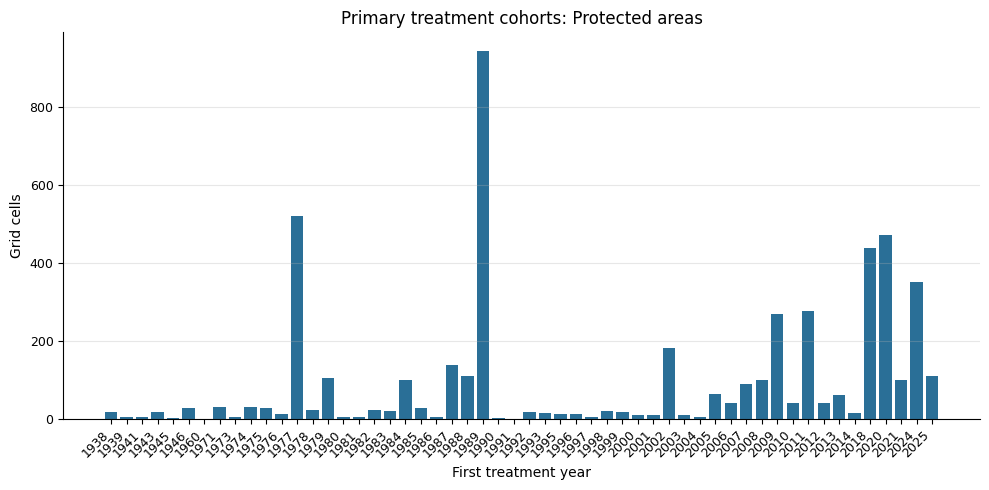

Saved figure: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\figures\02_treatment_type_grid_cells_0p080.png


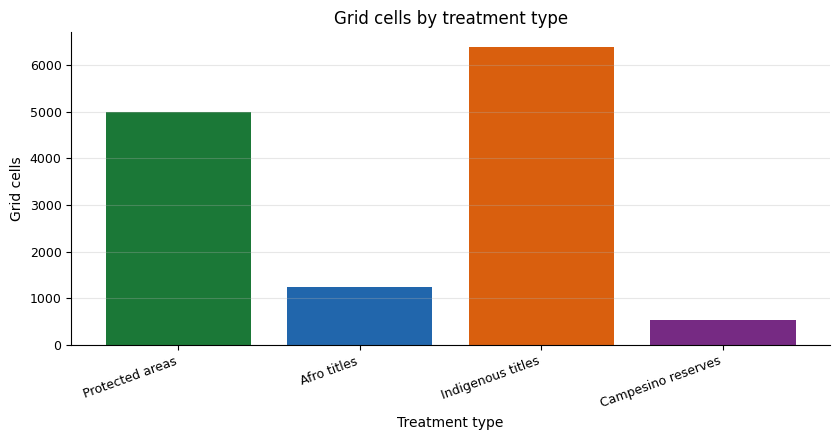

Saved figure: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\figures\02_titling_grid_cells_over_time_0p080.png


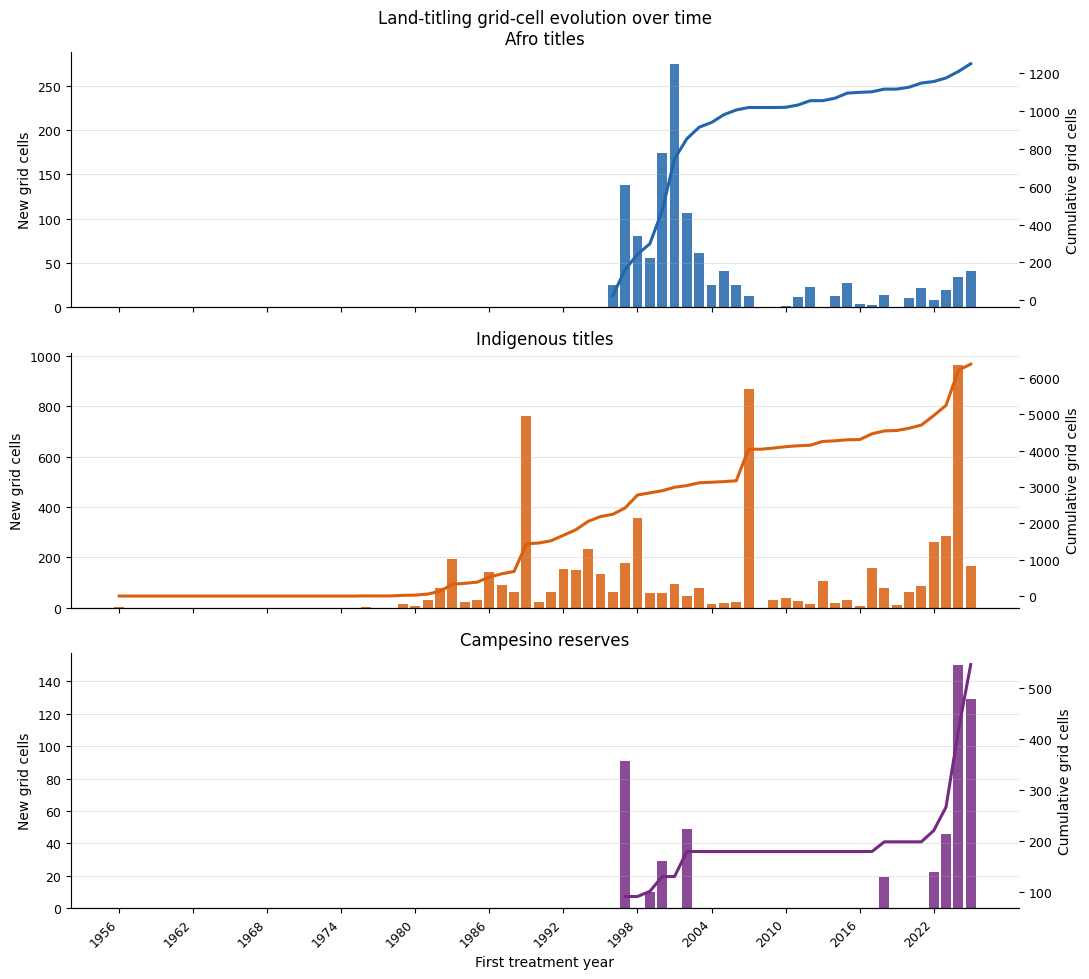

Saved figure: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\figures\02_wdpa_area_by_year_0p080.png


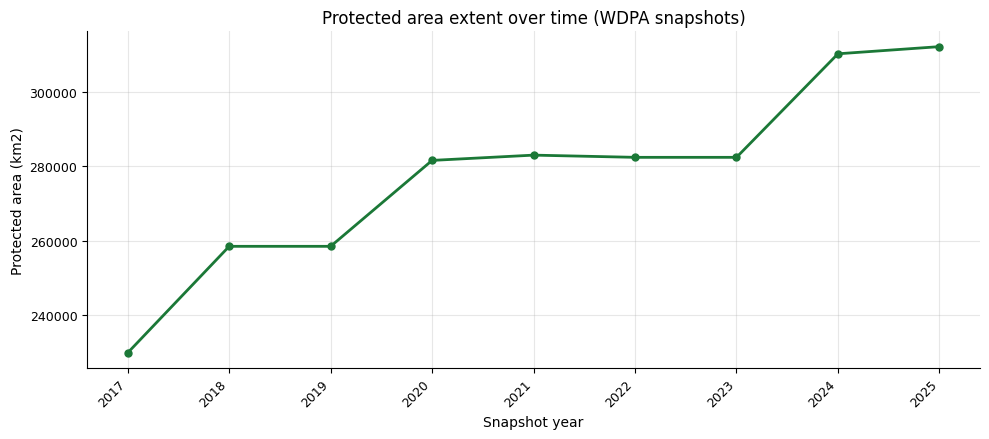

Saved figure: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\figures\02_land_title_area_by_year_0p080.png


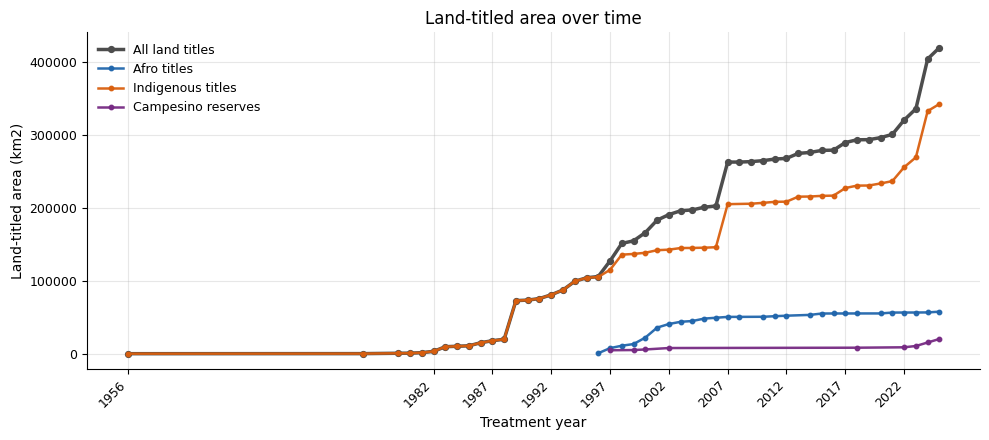

Saved figure: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\maps\02_map_avg_annual_loss_with_boundaries_hist_0p080.png


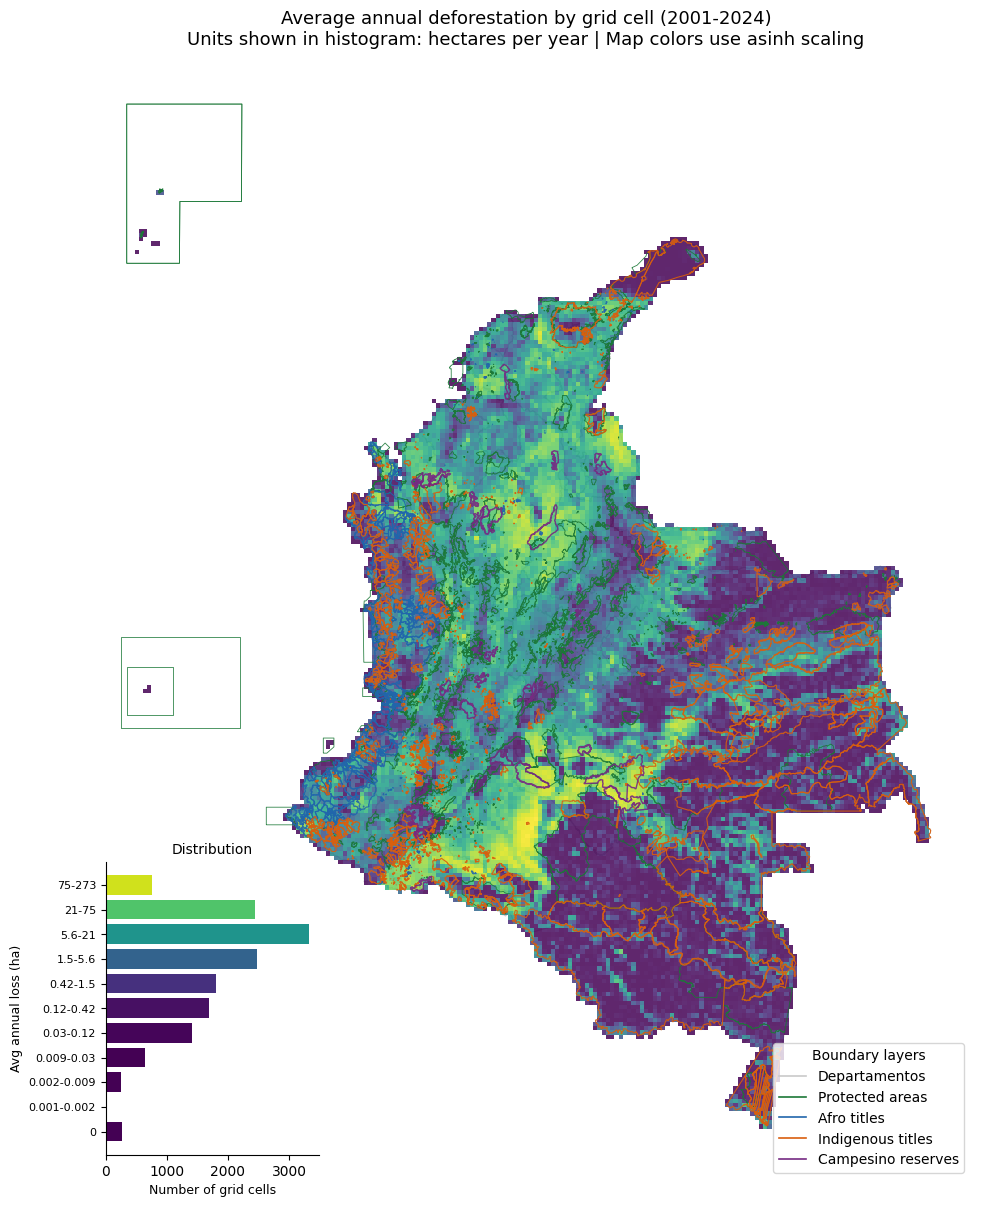

Saved interactive map: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\maps\02_interactive_avg_annual_loss_boundaries_0p080.html


In [46]:
from matplotlib import colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.geometry import MultiPolygon

cohort_fig_path = FIG_DIR / append_tag_to_filename(COHORT_FIG_NAME, run_tag)
wdpa_area_fig_path = FIG_DIR / append_tag_to_filename(WDPA_YEARLY_FIG_NAME, run_tag)
land_title_area_fig_path = FIG_DIR / append_tag_to_filename(LAND_TITLE_AREA_FIG_NAME, run_tag)
titling_grid_evolution_fig_path = FIG_DIR / append_tag_to_filename(TITLING_GRID_EVOLUTION_FIG_NAME, run_tag)
treatment_type_fig_path = FIG_DIR / append_tag_to_filename(TREATMENT_TYPE_FIG_NAME, run_tag)
loss_summary_map_path = MAP_DIR / append_tag_to_filename(LOSS_SUMMARY_MAP_NAME, run_tag)
interactive_loss_summary_map_path = MAP_DIR / append_tag_to_filename(INTERACTIVE_LOSS_SUMMARY_MAP_NAME, run_tag)

treatment_label_map = {
    "protected_area": "Protected areas",
    "afro": "Afro titles",
    "indigena": "Indigenous titles",
    "campesino": "Campesino reserves",
    "land_title_any": "Any land title",
}
treatment_color_map = {
    "protected_area": "#1b7837",
    "afro": "#2166ac",
    "indigena": "#d95f0e",
    "campesino": "#762a83",
    "land_title_any": "#5e3c99",
}

def treatment_display_name(key):
    return treatment_label_map.get(key, key.replace("_", " ").title())

def strip_frame(ax):
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

def union_area_km2(geo_series):
    if geo_series is None or len(geo_series) == 0:
        return 0.0
    union_geom = geo_series.union_all() if hasattr(geo_series, "union_all") else geo_series.unary_union
    return float(union_geom.area / 1_000_000.0) if union_geom is not None else 0.0

def clean_treatment_geometry_for_area(gdf):
    if gdf is None or gdf.empty or "treat_year" not in gdf.columns:
        return None
    frame = gdf[["treat_year", "geometry"]].copy()
    frame = frame[frame.geometry.notna()].copy()
    if frame.empty:
        return None
    try:
        frame["geometry"] = frame.geometry.make_valid()
    except Exception:
        pass
    frame = frame[frame.geometry.notna()].copy()
    frame["treat_year"] = pd.to_numeric(frame["treat_year"], errors="coerce").astype("Int64")
    frame = frame[frame["treat_year"].notna()].copy()
    if frame.empty:
        return None
    return frame.to_crs(AREA_CRS)

def build_cumulative_area_series(gdf):
    frame = clean_treatment_geometry_for_area(gdf)
    if frame is None or frame.empty:
        return pd.DataFrame(columns=["year", "union_area_km2"])
    yearly_rows = []
    for year in sorted(frame["treat_year"].dropna().astype(int).unique().tolist()):
        active = frame.loc[frame["treat_year"] <= int(year), "geometry"]
        yearly_rows.append({"year": int(year), "union_area_km2": union_area_km2(active)})
    return pd.DataFrame(yearly_rows)

def build_land_title_yearly_area_summary(layer_gdfs):
    frames = []
    for gdf in layer_gdfs:
        frame = clean_treatment_geometry_for_area(gdf)
        if frame is not None and not frame.empty:
            frames.append(frame)
    if not frames:
        return pd.DataFrame(columns=["year", "union_area_km2"])
    combined = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), geometry="geometry", crs=frames[0].crs)
    yearly_rows = []
    for year in sorted(combined["treat_year"].dropna().astype(int).unique().tolist()):
        active = combined.loc[combined["treat_year"] <= int(year), "geometry"]
        yearly_rows.append({"year": int(year), "union_area_km2": union_area_km2(active)})
    return pd.DataFrame(yearly_rows)

def build_treatment_yearly_cell_summary(cell_lookup_df, treatment_key):
    year_col = f"first_treat_year_{treatment_key}"
    if year_col not in cell_lookup_df.columns:
        return pd.DataFrame(columns=["year", "n_new_cells", "n_cumulative_cells"])
    years = pd.to_numeric(cell_lookup_df[year_col], errors="coerce").dropna().astype(int)
    if years.empty:
        return pd.DataFrame(columns=["year", "n_new_cells", "n_cumulative_cells"])
    yearly = years.value_counts().sort_index().rename_axis("year").reset_index(name="n_new_cells")
    full_years = pd.DataFrame({"year": range(int(yearly["year"].min()), int(yearly["year"].max()) + 1)})
    yearly = full_years.merge(yearly, on="year", how="left")
    yearly["n_new_cells"] = yearly["n_new_cells"].fillna(0).astype(int)
    yearly["n_cumulative_cells"] = yearly["n_new_cells"].cumsum()
    return yearly

primary_treatment_label = treatment_display_name(PRIMARY_TREATMENT_KEY)

if cohort_summary.empty:
    print("No treated cohorts were found for the selected primary treatment. Skipping the cohort-size figure.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(cohort_summary["cohort_year"].astype(int).astype(str), cohort_summary["n_cells"], color="#2a6f97")
    ax.set_title(f"Primary treatment cohorts: {primary_treatment_label}")
    ax.set_xlabel("First treatment year")
    ax.set_ylabel("Grid cells")
    ax.grid(axis="y", alpha=0.3)
    ax.xaxis.grid(False)
    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    strip_frame(ax)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    save_fig(cohort_fig_path)
    plt.show()

treatment_type_order = ["protected_area", "afro", "indigena", "campesino"]
treatment_type_summary = (
    layer_summary_df[layer_summary_df["treatment_key"].isin(treatment_type_order)]
    .set_index("treatment_key")
    .reindex(treatment_type_order)
    .reset_index()
)
treatment_type_summary["treatment_name"] = treatment_type_summary["treatment_key"].map(treatment_display_name)
treatment_type_summary["bar_color"] = treatment_type_summary["treatment_key"].map(treatment_color_map).fillna("#2a6f97")
treatment_type_summary = treatment_type_summary.dropna(subset=["n_treated_cells"]).reset_index(drop=True)
if treatment_type_summary.empty:
    print("Treatment-type summary is empty. Skipping the treatment-type figure.")
else:
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    ax.bar(
        treatment_type_summary["treatment_name"],
        treatment_type_summary["n_treated_cells"],
        color=treatment_type_summary["bar_color"],
    )
    ax.set_title("Grid cells by treatment type")
    ax.set_xlabel("Treatment type")
    ax.set_ylabel("Grid cells")
    ax.grid(axis="y", alpha=0.3)
    ax.xaxis.grid(False)
    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    strip_frame(ax)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    save_fig(treatment_type_fig_path)
    plt.show()

titling_keys = ["afro", "indigena", "campesino"]
titling_cell_summaries = {key: build_treatment_yearly_cell_summary(cell_treatment_lookup, key) for key in titling_keys}
nonempty_titling_summaries = {key: df for key, df in titling_cell_summaries.items() if not df.empty}
if not nonempty_titling_summaries:
    print("No titling grid-cell timing data were found. Skipping the titling grid-cell evolution figure.")
else:
    n_panels = len(nonempty_titling_summaries)
    fig, axes = plt.subplots(n_panels, 1, figsize=(11, 3.3 * n_panels), sharex=True)
    if n_panels == 1:
        axes = [axes]
    all_titling_years = sorted({int(year) for df in nonempty_titling_summaries.values() for year in df["year"].tolist()})
    tick_step = max(1, int(np.ceil(len(all_titling_years) / 12)))
    for idx, (ax, key) in enumerate(zip(axes, nonempty_titling_summaries.keys())):
        summary_df = nonempty_titling_summaries[key]
        color = treatment_color_map.get(key, "#2a6f97")
        ax2 = ax.twinx()
        ax.bar(summary_df["year"], summary_df["n_new_cells"], color=color, alpha=0.85, width=0.8)
        ax2.plot(summary_df["year"], summary_df["n_cumulative_cells"], color=color, linewidth=2.2)
        title_text = treatment_display_name(key)
        if idx == 0:
            title_text = f"Land-titling grid-cell evolution over time\n{title_text}"
        ax.set_title(title_text)
        ax.set_ylabel("New grid cells", fontsize=10)
        ax2.set_ylabel("Cumulative grid cells", fontsize=10)
        ax.grid(axis="y", alpha=0.3)
        ax.xaxis.grid(False)
        ax.tick_params(axis="y", labelsize=9)
        ax2.tick_params(axis="y", labelsize=9)
        strip_frame(ax)
        ax2.spines["top"].set_visible(False)
        ax2.spines["right"].set_visible(False)
        ax2.spines["left"].set_visible(False)
        ax2.grid(False)
    axes[-1].set_xlabel("First treatment year")
    axes[-1].set_xticks(all_titling_years[::tick_step])
    axes[-1].tick_params(axis="x", labelsize=9)
    plt.setp(axes[-1].get_xticklabels(), rotation=45, ha="right")
    save_fig(titling_grid_evolution_fig_path)
    plt.show()

if WDPA_ENABLED and not wdpa_yearly_summary_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(
        wdpa_yearly_summary_df["snapshot_year"],
        wdpa_yearly_summary_df["union_area_km2"],
        color="#1b7837",
        linewidth=2.0,
        marker="o",
        markersize=5,
    )
    ax.set_title("Protected area extent over time (WDPA snapshots)")
    ax.set_xlabel("Snapshot year")
    ax.set_ylabel("Protected area (km2)")
    ax.set_xticks(wdpa_yearly_summary_df["snapshot_year"].astype(int).tolist())
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    strip_frame(ax)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    fig.tight_layout()
    save_fig(wdpa_area_fig_path)
    plt.show()
else:
    print("WDPA yearly summary is empty. Skipping the protected-area-over-time figure.")

land_title_yearly_area_df = build_land_title_yearly_area_summary([afro_gdf, indigena_gdf, campesino_gdf])
land_title_area_by_type = {
    key: build_cumulative_area_series(gdf)
    for key, gdf in {"afro": afro_gdf, "indigena": indigena_gdf, "campesino": campesino_gdf}.items()
}
if land_title_yearly_area_df.empty:
    print("Land-titling area summary is empty. Skipping the land-titling-area figure.")
else:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(
        land_title_yearly_area_df["year"],
        land_title_yearly_area_df["union_area_km2"],
        color="#4d4d4d",
        linewidth=2.5,
        marker="o",
        markersize=4.2,
        label="All land titles",
    )
    for key in titling_keys:
        type_df = land_title_area_by_type.get(key)
        if type_df is None or type_df.empty:
            continue
        ax.plot(
            type_df["year"],
            type_df["union_area_km2"],
            color=treatment_color_map.get(key, "#2a6f97"),
            linewidth=1.8,
            marker="o",
            markersize=3.2,
            alpha=0.95,
            label=treatment_display_name(key),
        )
    ax.set_title("Land-titled area over time")
    ax.set_xlabel("Treatment year")
    ax.set_ylabel("Land-titled area (km2)")
    land_title_tick_years = land_title_yearly_area_df["year"].astype(int).tolist()
    tick_step = max(1, int(np.ceil(len(land_title_tick_years) / 12)))
    ax.set_xticks(land_title_tick_years[::tick_step])
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    strip_frame(ax)
    ax.legend(frameon=False, fontsize=9, loc="upper left")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    save_fig(land_title_area_fig_path)
    plt.show()

available_loss_years = sorted(
    int(year)
    for year in pd.Series(panel_df[PANEL_YEAR_COL]).dropna().astype(int).unique().tolist()
    if int(year) <= LOSS_YEAR_FOR_MAP
)
if not available_loss_years:
    raise ValueError(f"No panel years are available for the loss-summary map up to {LOSS_YEAR_FOR_MAP}.")

loss_summary = (
    panel_df.loc[panel_df[PANEL_YEAR_COL].isin(available_loss_years), [PANEL_CELL_ID_COL, "loss_m2"]]
    .copy()
)
loss_summary["loss_m2"] = loss_summary["loss_m2"].fillna(0)
loss_summary = loss_summary.groupby(PANEL_CELL_ID_COL, as_index=False).agg(cum_loss_m2=("loss_m2", "sum"))
loss_summary["avg_annual_loss_m2"] = loss_summary["cum_loss_m2"] / len(available_loss_years)
loss_summary["cum_loss_ha"] = loss_summary["cum_loss_m2"] / 10000.0
loss_summary["avg_annual_loss_ha"] = loss_summary["avg_annual_loss_m2"] / 10000.0
loss_summary = loss_summary.rename(columns={PANEL_CELL_ID_COL: GRID_CELL_ID_COL})

loss_map_df = grid_gdf[[GRID_CELL_ID_COL, "geometry"]].merge(
    loss_summary[[GRID_CELL_ID_COL, "cum_loss_ha", "avg_annual_loss_ha"]],
    on=GRID_CELL_ID_COL,
    how="left",
)
loss_map_df["cum_loss_ha"] = loss_map_df["cum_loss_ha"].fillna(0)
loss_map_df["avg_annual_loss_ha"] = loss_map_df["avg_annual_loss_ha"].fillna(0)

def extract_polygonal_geometry(geom):
    if geom is None or geom.is_empty:
        return None
    if geom.geom_type in {"Polygon", "MultiPolygon"}:
        return geom
    if geom.geom_type == "GeometryCollection":
        polygon_parts = []
        for part in geom.geoms:
            if part.is_empty:
                continue
            if part.geom_type == "Polygon":
                polygon_parts.append(part)
            elif part.geom_type == "MultiPolygon":
                polygon_parts.extend([subgeom for subgeom in part.geoms if not subgeom.is_empty])
        if not polygon_parts:
            return None
        if len(polygon_parts) == 1:
            return polygon_parts[0]
        return MultiPolygon(polygon_parts)
    return None

def polygon_only_gdf(gdf):
    if gdf is None:
        return None
    out = gdf.copy()
    if out.empty:
        return out
    out["geometry"] = out.geometry.apply(extract_polygonal_geometry)
    out = out[out.geometry.notna()].copy()
    out = out.loc[~out.geometry.is_empty].copy()
    return out

plot_crs = grid_gdf.crs if grid_gdf.crs is not None else "EPSG:4326"
departamentos_plot = polygon_only_gdf(departamentos_gdf).to_crs(plot_crs)
wdpa_plot = polygon_only_gdf(protected_area_display_gdf)
wdpa_plot = wdpa_plot.to_crs(plot_crs) if wdpa_plot is not None and not wdpa_plot.empty else wdpa_plot
afro_plot = polygon_only_gdf(afro_gdf).to_crs(plot_crs)
indigena_plot = polygon_only_gdf(indigena_gdf).to_crs(plot_crs)
campesino_plot = polygon_only_gdf(campesino_gdf).to_crs(plot_crs)

AVG_COL_RAW = "avg_annual_loss_ha"
AVG_COL_COLOR = "_avg_annual_loss_color"

plot_df = loss_map_df.copy()
plot_df[AVG_COL_RAW] = plot_df[AVG_COL_RAW].fillna(0)
plot_df[AVG_COL_COLOR] = np.arcsinh(plot_df[AVG_COL_RAW].clip(lower=0))
color_note = "Map colors use asinh scaling"

cmap = plt.cm.viridis
vmin = float(plot_df[AVG_COL_COLOR].min())
vmax = float(plot_df[AVG_COL_COLOR].max())
if vmax <= vmin:
    vmax = vmin + 1e-9
norm = colors.Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
departamentos_plot.plot(ax=ax, color="white", edgecolor="#c9c9c9", linewidth=0.8, alpha=1.0)
plot_df.plot(
    column=AVG_COL_COLOR,
    ax=ax,
    cmap="viridis",
    linewidth=0,
    legend=False,
    alpha=0.85,
    missing_kwds={"color": "lightgrey"},
)

if wdpa_plot is not None and not wdpa_plot.empty:
    wdpa_plot.boundary.plot(ax=ax, color="#1b7837", linewidth=0.6, alpha=0.9)
afro_plot.boundary.plot(ax=ax, color="#2166ac", linewidth=0.8, alpha=0.9)
indigena_plot.boundary.plot(ax=ax, color="#d95f0e", linewidth=0.8, alpha=0.9)
campesino_plot.boundary.plot(ax=ax, color="#762a83", linewidth=1.0, alpha=0.9)

ax.set_title(
    f"Average annual deforestation by grid cell ({available_loss_years[0]}-{available_loss_years[-1]})\n"
    f"Units shown in histogram: hectares per year | {color_note}",
    fontsize=13,
)
ax.set_axis_off()

legend_handles = [
    mlines.Line2D([], [], color="#c9c9c9", linewidth=1.2, label="Departamentos"),
    mlines.Line2D([], [], color="#1b7837", linewidth=1.2, label="Protected areas"),
    mlines.Line2D([], [], color="#2166ac", linewidth=1.2, label="Afro titles"),
    mlines.Line2D([], [], color="#d95f0e", linewidth=1.2, label="Indigenous titles"),
    mlines.Line2D([], [], color="#762a83", linewidth=1.2, label="Campesino reserves"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=True, title="Boundary layers")

hist_values = plot_df[AVG_COL_RAW].fillna(0).to_numpy()
HIST_BIN_STYLE = "log"
HIST_N_BINS = 10
SHOW_ZERO_BIN = True
HIST_WIDTH = "24%"
HIST_HEIGHT = "26%"
HIST_LOC = "lower left"
HIST_BORDERPAD = 1.8

positive_vals = hist_values[hist_values > 0]
zero_count = int((hist_values == 0).sum())

if HIST_BIN_STYLE == "equal":
    if len(positive_vals) == 0:
        pos_edges = np.array([0, 1])
    else:
        pos_edges = np.histogram_bin_edges(positive_vals, bins=HIST_N_BINS)
elif HIST_BIN_STYLE == "log":
    if len(positive_vals) == 0:
        pos_edges = np.array([0, 1])
    else:
        hist_vmin = positive_vals.min()
        hist_vmax = positive_vals.max()
        pos_edges = np.geomspace(hist_vmin, hist_vmax, HIST_N_BINS + 1)
        pos_edges = np.unique(pos_edges)
        if len(pos_edges) < 3:
            pos_edges = np.histogram_bin_edges(positive_vals, bins=HIST_N_BINS)
else:
    raise ValueError("HIST_BIN_STYLE must be 'equal' or 'log'")

pos_counts, pos_edges = np.histogram(positive_vals, bins=pos_edges)
pos_centers = (pos_edges[:-1] + pos_edges[1:]) / 2

def fmt_bin_value(x):
    if x == 0:
        return "0"
    if x < 0.01:
        return f"{x:.3f}"
    if x < 0.1:
        return f"{x:.2f}"
    if x < 1:
        return f"{x:.2f}"
    if x < 10:
        return f"{x:.1f}"
    return f"{x:.0f}"

pos_labels = [
    f"{fmt_bin_value(pos_edges[i])}-{fmt_bin_value(pos_edges[i + 1])}"
    for i in range(len(pos_edges) - 1)
]
pos_color_values = np.arcsinh(np.clip(pos_centers, a_min=0, a_max=None))
zero_color_value = np.arcsinh(0.0)
pos_bar_colors = cmap(norm(pos_color_values))

hist_counts = pos_counts.tolist()
hist_labels = pos_labels.copy()
hist_colors = list(pos_bar_colors)

if SHOW_ZERO_BIN:
    hist_counts = [zero_count] + hist_counts
    hist_labels = ["0"] + hist_labels
    hist_colors = [cmap(norm(zero_color_value))] + hist_colors

ax_hist = inset_axes(
    ax,
    width=HIST_WIDTH,
    height=HIST_HEIGHT,
    loc=HIST_LOC,
    borderpad=HIST_BORDERPAD,
)
ax_hist.barh(np.arange(len(hist_counts)), hist_counts, color=hist_colors, edgecolor="none")
ax_hist.set_yticks(np.arange(len(hist_counts)))
ax_hist.set_yticklabels(hist_labels, fontsize=8)
ax_hist.set_xlabel("Number of grid cells", fontsize=9)
ax_hist.set_ylabel("Avg annual loss (ha)", fontsize=9)
ax_hist.set_title("Distribution", fontsize=10)
ax_hist.grid(False)
for spine in ["top", "right"]:
    ax_hist.spines[spine].set_visible(False)
ax_hist.set_facecolor("white")

fig.tight_layout()
save_fig(loss_summary_map_path)
plt.show()

try:
    import branca.colormap as bcm
    import folium
except ImportError as exc:
    print(f"Interactive map skipped because folium/branca is unavailable: {exc}")
else:
    interactive_plot_df = plot_df[[GRID_CELL_ID_COL, "geometry", "cum_loss_ha", "avg_annual_loss_ha"]].copy()
    interactive_plot_df["cum_loss_ha"] = interactive_plot_df["cum_loss_ha"].round(2)
    interactive_plot_df["avg_annual_loss_ha"] = interactive_plot_df["avg_annual_loss_ha"].round(4)
    interactive_plot_df[AVG_COL_COLOR] = np.arcsinh(interactive_plot_df["avg_annual_loss_ha"].clip(lower=0))
    interactive_plot_df = interactive_plot_df.to_crs(4326)

    bounds = interactive_plot_df.total_bounds
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]

    interactive_cmap = bcm.LinearColormap(
        colors=[
            "#440154", "#482878", "#3e4989", "#31688e", "#26828e",
            "#1f9e89", "#35b779", "#6ece58", "#b5de2b", "#fde725",
        ],
        vmin=vmin,
        vmax=vmax,
    )
    interactive_cmap.caption = "Average annual forest loss (ha/year), colors use asinh scaling"

    m = folium.Map(location=center, zoom_start=5, tiles=None)
    folium.TileLayer("CartoDB positron", name="Basemap", control=False).add_to(m)

    folium.GeoJson(
        data=interactive_plot_df.to_json(),
        name="Avg annual deforestation",
        style_function=lambda feature, cm=interactive_cmap: {
            "fillColor": cm(feature["properties"][AVG_COL_COLOR]),
            "color": "transparent",
            "weight": 0,
            "fillOpacity": 0.75,
            "interactive": False,
        },
        smooth_factor=0.2,
        control=False,
    ).add_to(m)

    dept_df = polygon_only_gdf(departamentos_gdf)
    if dept_df is not None and not dept_df.empty:
        dept_df = dept_df.to_crs(4326)
        folium.GeoJson(
            data=dept_df.to_json(),
            name="Departamentos",
            style_function=lambda feature: {
                "color": "#9e9e9e",
                "weight": 1.0,
                "fillOpacity": 0.0,
                "opacity": 0.8,
                "interactive": False,
            },
            smooth_factor=0.2,
        ).add_to(m)

    def first_existing_column(columns, candidates):
        for col in candidates:
            if col in columns:
                return col
        return None

    loss_cells_area = loss_map_df[[GRID_CELL_ID_COL, "avg_annual_loss_ha", "cum_loss_ha", "geometry"]].copy().to_crs(AREA_CRS)
    loss_cells_area["_cell_area_ha"] = loss_cells_area.geometry.area / 10000.0

    def build_boundary_summary_gdf(source_gdf, layer_name, name_candidates, id_candidates):
        boundary_df = polygon_only_gdf(source_gdf)
        if boundary_df is None or boundary_df.empty:
            return None

        boundary_df = boundary_df.reset_index(drop=True).copy()
        boundary_df["_boundary_row_id"] = np.arange(len(boundary_df))

        name_col = first_existing_column(boundary_df.columns, name_candidates)
        id_col = first_existing_column(boundary_df.columns, id_candidates)

        if name_col is not None:
            boundary_df["boundary_name"] = boundary_df[name_col].fillna("").astype(str).str.strip()
        else:
            boundary_df["boundary_name"] = ""
        if id_col is not None:
            boundary_df["boundary_id"] = boundary_df[id_col].fillna("").astype(str).str.strip()
        else:
            boundary_df["boundary_id"] = ""

        boundary_df["boundary_name"] = boundary_df["boundary_name"].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
        boundary_df["boundary_id"] = boundary_df["boundary_id"].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})

        fallback_names = pd.Series([f"{layer_name} {i + 1}" for i in range(len(boundary_df))], index=boundary_df.index)
        boundary_df["boundary_name"] = boundary_df["boundary_name"].fillna(boundary_df["boundary_id"]).fillna(fallback_names)
        boundary_df["boundary_id"] = boundary_df["boundary_id"].fillna(fallback_names)
        boundary_df["boundary_layer"] = layer_name

        boundary_area = boundary_df[["_boundary_row_id", "geometry"]].copy().to_crs(AREA_CRS)
        boundary_area["boundary_area_ha"] = boundary_area.geometry.area / 10000.0

        candidate_pairs = gpd.sjoin(
            boundary_area[["_boundary_row_id", "geometry"]],
            loss_cells_area[[GRID_CELL_ID_COL, "geometry"]],
            predicate="intersects",
            how="inner",
        )

        if candidate_pairs.empty:
            summary = pd.DataFrame(
                {
                    "_boundary_row_id": boundary_area["_boundary_row_id"],
                    "boundary_avg_annual_loss_ha": 0.0,
                    "boundary_cum_loss_ha": 0.0,
                    "intersecting_cells": 0,
                }
            )
        else:
            candidate_cells = loss_cells_area.loc[
                candidate_pairs["index_right"].unique(),
                [GRID_CELL_ID_COL, "avg_annual_loss_ha", "cum_loss_ha", "_cell_area_ha", "geometry"],
            ].copy()
            candidate_boundaries = boundary_area[
                boundary_area["_boundary_row_id"].isin(candidate_pairs["_boundary_row_id"].unique())
            ].copy()

            intersections = gpd.overlay(
                candidate_boundaries,
                candidate_cells,
                how="intersection",
                keep_geom_type=False,
            )

            if intersections.empty:
                summary = pd.DataFrame(
                    {
                        "_boundary_row_id": boundary_area["_boundary_row_id"],
                        "boundary_avg_annual_loss_ha": 0.0,
                        "boundary_cum_loss_ha": 0.0,
                        "intersecting_cells": 0,
                    }
                )
            else:
                intersections["intersection_area_ha"] = intersections.geometry.area / 10000.0
                intersections = intersections[intersections["intersection_area_ha"] > 0].copy()
                intersections["cell_overlap_share"] = (
                    intersections["intersection_area_ha"]
                    / intersections["_cell_area_ha"].replace(0, np.nan)
                ).clip(lower=0, upper=1).fillna(0)
                intersections["weighted_avg_annual_loss_ha"] = (
                    intersections["avg_annual_loss_ha"] * intersections["cell_overlap_share"]
                )
                intersections["weighted_cum_loss_ha"] = (
                    intersections["cum_loss_ha"] * intersections["cell_overlap_share"]
                )
                summary = intersections.groupby("_boundary_row_id", as_index=False).agg(
                    boundary_avg_annual_loss_ha=("weighted_avg_annual_loss_ha", "sum"),
                    boundary_cum_loss_ha=("weighted_cum_loss_ha", "sum"),
                    intersecting_cells=(GRID_CELL_ID_COL, "nunique"),
                )

        boundary_df = boundary_df.merge(
            boundary_area[["_boundary_row_id", "boundary_area_ha"]],
            on="_boundary_row_id",
            how="left",
        )
        boundary_df = boundary_df.merge(summary, on="_boundary_row_id", how="left")
        boundary_df["boundary_avg_annual_loss_ha"] = boundary_df["boundary_avg_annual_loss_ha"].fillna(0.0)
        boundary_df["boundary_cum_loss_ha"] = boundary_df["boundary_cum_loss_ha"].fillna(0.0)
        boundary_df["intersecting_cells"] = boundary_df["intersecting_cells"].fillna(0).astype(int)
        boundary_df["boundary_loss_rate_pct"] = np.where(
            boundary_df["boundary_area_ha"] > 0,
            100.0 * boundary_df["boundary_avg_annual_loss_ha"] / boundary_df["boundary_area_ha"],
            np.nan,
        )

        if "treat_year" in boundary_df.columns:
            boundary_df["treat_year_display"] = (
                boundary_df["treat_year"].astype("Int64").astype(str).replace("<NA>", "n/a")
            )
        else:
            boundary_df["treat_year_display"] = "n/a"

        boundary_df["boundary_area_ha"] = boundary_df["boundary_area_ha"].round(2)
        boundary_df["boundary_avg_annual_loss_ha"] = boundary_df["boundary_avg_annual_loss_ha"].round(4)
        boundary_df["boundary_cum_loss_ha"] = boundary_df["boundary_cum_loss_ha"].round(2)
        boundary_df["boundary_loss_rate_pct"] = boundary_df["boundary_loss_rate_pct"].round(5)

        boundary_df = boundary_df.sort_values("boundary_area_ha", ascending=False).to_crs(4326)
        return boundary_df

    def add_interactive_boundary_layer(boundary_summary_gdf, layer_name, color, show=True):
        if boundary_summary_gdf is None or boundary_summary_gdf.empty:
            return
        tooltip_fields = [
            "boundary_layer",
            "boundary_name",
            "treat_year_display",
            "boundary_avg_annual_loss_ha",
            "boundary_loss_rate_pct",
        ]
        popup_fields = [
            "boundary_layer",
            "boundary_name",
            "boundary_id",
            "treat_year_display",
            "boundary_area_ha",
            "boundary_avg_annual_loss_ha",
            "boundary_loss_rate_pct",
            "boundary_cum_loss_ha",
            "intersecting_cells",
        ]
        geojson_fields = list(dict.fromkeys(tooltip_fields + popup_fields + ["geometry"]))
        boundary_geojson = boundary_summary_gdf[geojson_fields].copy()
        folium.GeoJson(
            data=boundary_geojson.to_json(),
            name=layer_name,
            style_function=lambda feature, c=color: {
                "color": c,
                "weight": 1.2,
                "fillColor": c,
                "fillOpacity": 0.03,
                "opacity": 0.95,
            },
            highlight_function=lambda feature, c=color: {
                "color": c,
                "weight": 2.4,
                "fillColor": c,
                "fillOpacity": 0.14,
                "opacity": 1.0,
            },
            tooltip=folium.GeoJsonTooltip(
                fields=tooltip_fields,
                aliases=[
                    "Layer",
                    "Boundary",
                    "Treatment year",
                    "Avg annual loss (ha/year)",
                    "Avg annual loss (% boundary area)",
                ],
                localize=True,
                labels=True,
                sticky=False,
            ),
            popup=folium.GeoJsonPopup(
                fields=popup_fields,
                aliases=[
                    "Layer",
                    "Boundary",
                    "ID",
                    "Treatment year",
                    "Boundary area (ha)",
                    "Avg annual loss (ha/year)",
                    "Avg annual loss (% boundary area)",
                    "Cumulative loss (ha)",
                    "Intersecting grid cells",
                ],
                localize=True,
                labels=True,
            ),
            smooth_factor=0.2,
            show=show,
        ).add_to(m)

    protected_summary_gdf = build_boundary_summary_gdf(
        protected_area_display_gdf,
        "Protected areas",
        name_candidates=["boundary_name", "NAME", "NAME_ENG", "DESIG_ENG", "DESIG", "SITE_ID"],
        id_candidates=["boundary_id", "wdpa_site_id", "SITE_ID", "WDPAID", "SITE_PID", "METADATAID"],
    )
    afro_summary_gdf = build_boundary_summary_gdf(
        afro_gdf,
        "Afro titles",
        name_candidates=["NOMBRE", "DEPARTAMEN", "ID"],
        id_candidates=["ID", "OBJECTID"],
    )
    indigena_summary_gdf = build_boundary_summary_gdf(
        indigena_gdf,
        "Indigenous titles",
        name_candidates=["NOMBRE", "PUEBLO", "ID"],
        id_candidates=["ID", "OBJECTID"],
    )
    campesino_summary_gdf = build_boundary_summary_gdf(
        campesino_gdf,
        "Campesino reserves",
        name_candidates=["NOMBRE_ZON", "MUNICIPIOS", "ID_ZRC_C"],
        id_candidates=["ID_ZRC_C", "OBJECTID", "OBJECTID_1"],
    )

    add_interactive_boundary_layer(protected_summary_gdf, "Protected areas", "#1b7837", True)
    add_interactive_boundary_layer(afro_summary_gdf, "Afro titles", "#2166ac", True)
    add_interactive_boundary_layer(indigena_summary_gdf, "Indigenous titles", "#d95f0e", True)
    add_interactive_boundary_layer(campesino_summary_gdf, "Campesino reserves", "#762a83", True)

    interactive_cmap.add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)

    m.save(str(interactive_loss_summary_map_path))
    print("Saved interactive map:", interactive_loss_summary_map_path)


## Final notes

At the end of this notebook, the main outputs for the next steps are:

- `data/intermediate/panel_treatment.parquet` with generic primary-treatment columns plus the full layer-specific timing columns,
- `data/intermediate/cell_treatment_lookup.parquet`,
- `outputs/tables/02_treatment_layer_summary.csv`,
- `outputs/tables/02_primary_cohort_summary.csv`,
- `outputs/tables/02_wdpa_area_by_year.csv`,
- `outputs/tables/02_treatment_timing_summary.json`,
- `outputs/figures/02_primary_cohort_sizes.png`,
- `outputs/figures/02_treatment_type_grid_cells.png`,
- `outputs/figures/02_wdpa_area_by_year.png`,
- `outputs/figures/02_land_title_area_by_year.png`,
- `outputs/figures/02_titling_grid_cells_over_time.png`,
- `outputs/maps/02_map_avg_annual_loss_with_boundaries_hist.png`,
- `outputs/maps/02_interactive_avg_annual_loss_boundaries.html`.

The protected-area treatment is now built from yearly WDPA snapshots, cached locally in `data/intermediate/wdpa_colombia_yearly_snapshots.geojson`. Cells first protected in the earliest available WDPA snapshot are backfilled with `STATUS_YR` when that field is available, while later entrants use the first yearly snapshot in which the cell becomes protected.

The departamento background is auto-detected from the local `departamentos` folder. The next notebook can now build spatial structure and exposure mappings on top of this treatment-enriched panel.
